# Universidad de Antioquia
## Facultad de Ingeniería – Departamento de Ingeniería Electrónica y de Telecomunicaciones
### Comunicaciones Digitales

---

# Proyecto Final
## Diseño e implementación de un módem óptico espacio-temporal half-duplex pantalla–cámara

---

### **Estudiantes**
- **Daniel Felipe Yépez Taimal**
- **Juan Manuel Rivera Florez**

### **Docente**
- **Prof. Daniel Ospina Acero, PhD**

### **Semestre**
**2026-1**

---

### Medellín, Colombia
### Universidad de Antioquia

# Transmisión mediante OKK

#  Fase A

## Definición inicial del sistema

Para la primera implementación de la Fase A se seleccionó una transmisión mediante **OOK (On-Off Keying)** con codificación **Manchester**, debido a su simplicidad y facilidad de validación en simulación.

Se definió una ventana de transmisión de **1280 × 720 píxeles**, correspondiente a resolución HD, con el fin de disponer de suficiente espacio para la grilla visual y garantizar buena visualización en pantalla.

Cada símbolo se representa mediante una celda de **20 × 20 píxeles**, obteniendo una matriz de **36 filas × 64 columnas**.

La codificación utilizada será:

- **0 → negro**
- **1 → blanco**

y posteriormente cada bit se transformará mediante Manchester:

- **0 → 01**
- **1 → 10**

Con esta configuración se busca validar inicialmente la cadena completa:

**texto → bits → Manchester → OOK → grilla → imagen**,

antes de incorporar marcadores, pilotos y recepción con cámara.

### Conversión del mensaje a ASCII y binario

Como primera etapa del transmisor se implementa la conversión del mensaje de texto a su representación binaria.

Cada carácter del mensaje se transforma a su valor ASCII decimal y posteriormente a binario de 8 bits.

In [153]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

Mensaje original:
por favor no quiero perder comunicaciones digitales

ASCII decimal:
[112, 111, 114, 32, 102, 97, 118, 111, 114, 32, 110, 111, 32, 113, 117, 105, 101, 114, 111, 32, 112, 101, 114, 100, 101, 114, 32, 99, 111, 109, 117, 110, 105, 99, 97, 99, 105, 111, 110, 101, 115, 32, 100, 105, 103, 105, 116, 97, 108, 101, 115]

Secuencia binaria total:
011100000110111101110010001000000110011001100001011101100110111101110010001000000110111001101111001000000111000101110101011010010110010101110010011011110010000001110000011001010111001001100100011001010111001000100000011000110110111101101101011101010110111001101001011000110110000101100011011010010110111101101110011001010111001100100000011001000110100101100111011010010111010001100001011011000110010101110011


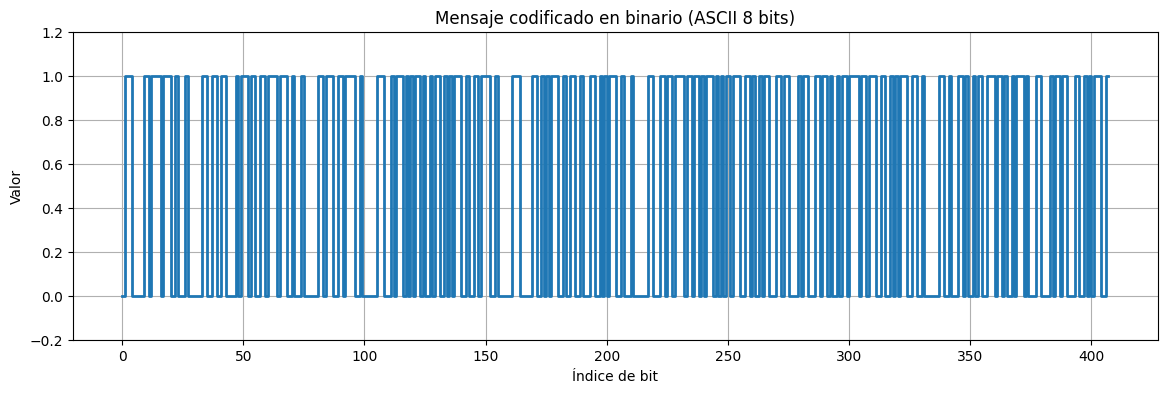

In [154]:
mensaje = "por favor no quiero perder comunicaciones digitales"

print("Mensaje original:")
print(mensaje)

ascii_vals = [ord(c) for c in mensaje]

print("\nASCII decimal:")
print(ascii_vals)

binarios = [format(valor, "08b") for valor in ascii_vals]

bits = "".join(binarios)

print("\nSecuencia binaria total:")
print(bits)

bits_array = np.array([int(b) for b in bits])

plt.figure(figsize=(14,4))

plt.step(
    np.arange(len(bits_array)),
    bits_array,
    where="post",
    linewidth=2
)

plt.ylim(-0.2, 1.2)

plt.xlabel("Índice de bit")
plt.ylabel("Valor")

plt.title("Mensaje codificado en binario (ASCII 8 bits)")

plt.grid(True)

plt.show()


### Codificación Manchester

En esta etapa se aplica codificación Manchester a la secuencia binaria obtenida desde el mensaje ASCII.

La convención utilizada es:

- Bit `0` → `01`
- Bit `1` → `10`

Con esta codificación, cada bit original se representa mediante dos bits codificados. Esto permite balancear el brillo promedio de la transmisión y evita secuencias largas de símbolos iguales.

In [155]:
def codificar_manchester(bits_array):
    bits_manchester = []

    for bit in bits_array:
        if bit == 0:
            bits_manchester.extend([0, 1])
        elif bit == 1:
            bits_manchester.extend([1, 0])
        else:
            raise ValueError("La secuencia solo debe contener bits 0 o 1.")

    return np.array(bits_manchester)


bits_manchester = codificar_manchester(bits_array)

print("Cantidad de bits originales:", len(bits_array))
print("Cantidad de bits Manchester:", len(bits_manchester))

print("\nPrimeros bits originales:")
print(bits_array[:32])

print("\nPrimeros bits Manchester:")
print(bits_manchester[:64])

Cantidad de bits originales: 408
Cantidad de bits Manchester: 816

Primeros bits originales:
[0 1 1 1 0 0 0 0 0 1 1 0 1 1 1 1 0 1 1 1 0 0 1 0 0 0 1 0 0 0 0 0]

Primeros bits Manchester:
[0 1 1 0 1 0 1 0 0 1 0 1 0 1 0 1 0 1 1 0 1 0 0 1 1 0 1 0 1 0 1 0 0 1 1 0 1
 0 1 0 0 1 0 1 1 0 0 1 0 1 0 1 1 0 0 1 0 1 0 1 0 1 0 1]


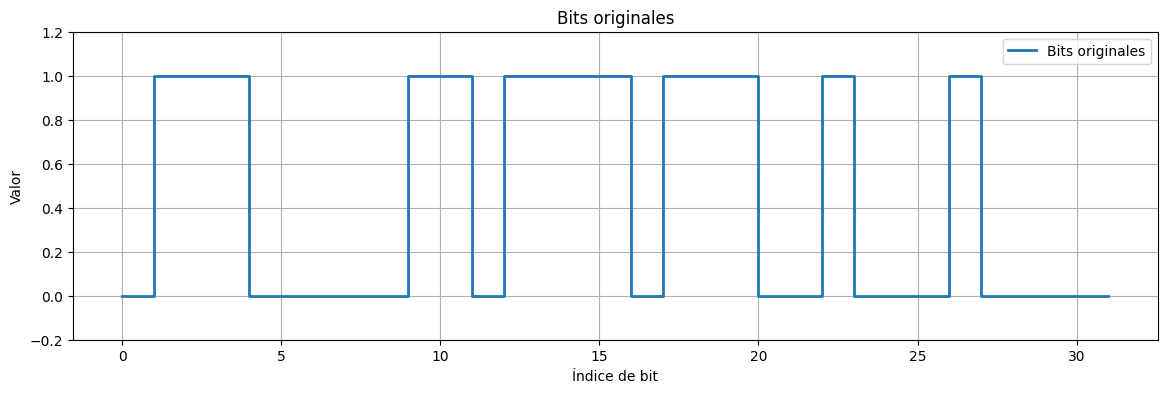

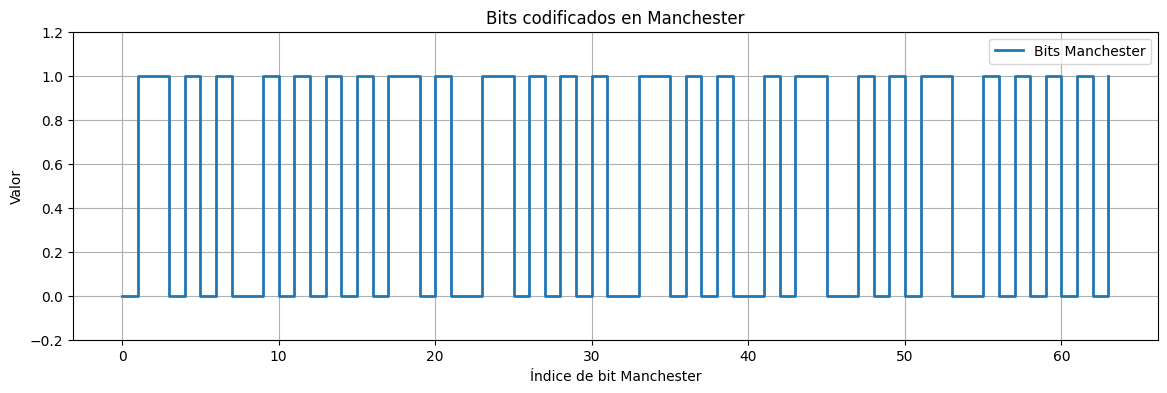

In [156]:
num_bits_mostrar = 32

plt.figure(figsize=(14,4))
plt.step(
    np.arange(num_bits_mostrar),
    bits_array[:num_bits_mostrar],
    where="post",
    linewidth=2,
    label="Bits originales"
)

plt.ylim(-0.2, 1.2)
plt.xlabel("Índice de bit")
plt.ylabel("Valor")
plt.title("Bits originales")
plt.grid(True)
plt.legend()
plt.show()


plt.figure(figsize=(14,4))
plt.step(
    np.arange(2*num_bits_mostrar),
    bits_manchester[:2*num_bits_mostrar],
    where="post",
    linewidth=2,
    label="Bits Manchester"
)

plt.ylim(-0.2, 1.2)
plt.xlabel("Índice de bit Manchester")
plt.ylabel("Valor")
plt.title("Bits codificados en Manchester")
plt.grid(True)
plt.legend()
plt.show()

### Modulación OOK

En esta etapa se realiza la modulación OOK sobre la secuencia codificada en Manchester.

Cada bit Manchester se convierte en un nivel de intensidad en escala de grises:

- `0` → intensidad baja
- `1` → intensidad alta

Estos niveles serán posteriormente ubicados dentro de la grilla espacial de transmisión.

In [157]:
nivel_bajo = 0      # negro
nivel_alto = 255    # blanco

simbolos_ook = np.where(bits_manchester == 0, nivel_bajo, nivel_alto)

print("Cantidad de símbolos OOK:", len(simbolos_ook))

print("\nPrimeros bits Manchester:")
print(bits_manchester[:32])

print("\nPrimeros símbolos OOK:")
print(simbolos_ook[:32])

Cantidad de símbolos OOK: 816

Primeros bits Manchester:
[0 1 1 0 1 0 1 0 0 1 0 1 0 1 0 1 0 1 1 0 1 0 0 1 1 0 1 0 1 0 1 0]

Primeros símbolos OOK:
[  0 255 255   0 255   0 255   0   0 255   0 255   0 255   0 255   0 255
 255   0 255   0   0 255 255   0 255   0 255   0 255   0]


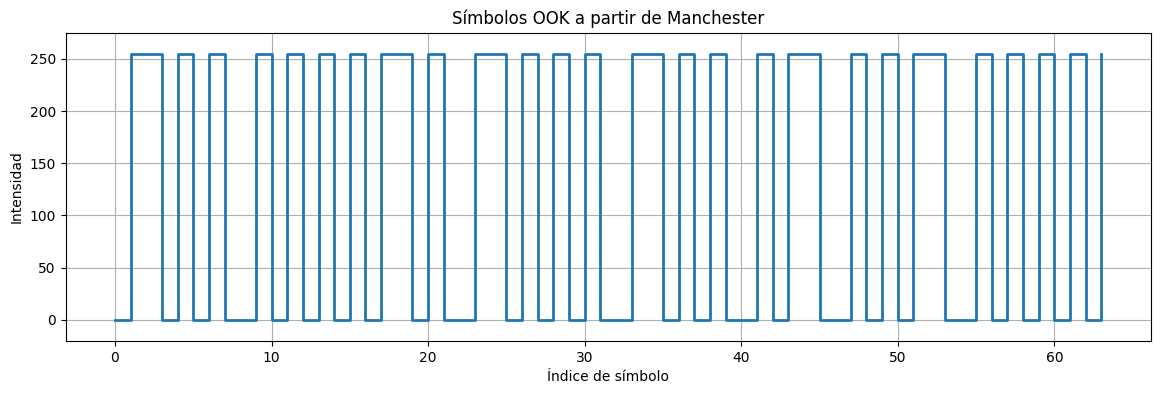

In [158]:
num_simbolos_mostrar = 64

plt.figure(figsize=(14,4))

plt.step(
    np.arange(num_simbolos_mostrar),
    simbolos_ook[:num_simbolos_mostrar],
    where="post",
    linewidth=2
)

plt.ylim(-20, 275)
plt.xlabel("Índice de símbolo")
plt.ylabel("Intensidad")
plt.title("Símbolos OOK a partir de Manchester")
plt.grid(True)

plt.show()

### Mapeo de símbolos en la matriz de transmisión

En esta etapa los símbolos OOK se ubican espacialmente dentro de la grilla de transmisión.

La ventana definida es de 1280 × 720 píxeles, con celdas de 20 × 20 píxeles. Por tanto, se obtiene una matriz de 36 filas por 64 columnas.

Cada posición de la matriz representa una celda visual que transporta un símbolo OOK.

In [159]:
ancho_img = 1280
alto_img = 720

tam_celda = 20

num_columnas = ancho_img // tam_celda
num_filas = alto_img // tam_celda

total_celdas = num_filas * num_columnas

print("Número de filas:", num_filas)
print("Número de columnas:", num_columnas)
print("Total de celdas:", total_celdas)

if len(simbolos_ook) > total_celdas:
    raise ValueError("El mensaje es demasiado largo para la grilla definida.")

matriz_tx = np.zeros(total_celdas, dtype=np.uint8)

matriz_tx[:len(simbolos_ook)] = simbolos_ook

matriz_tx = matriz_tx.reshape((num_filas, num_columnas))

print("Forma de la matriz de transmisión:", matriz_tx.shape)

Número de filas: 36
Número de columnas: 64
Total de celdas: 2304
Forma de la matriz de transmisión: (36, 64)


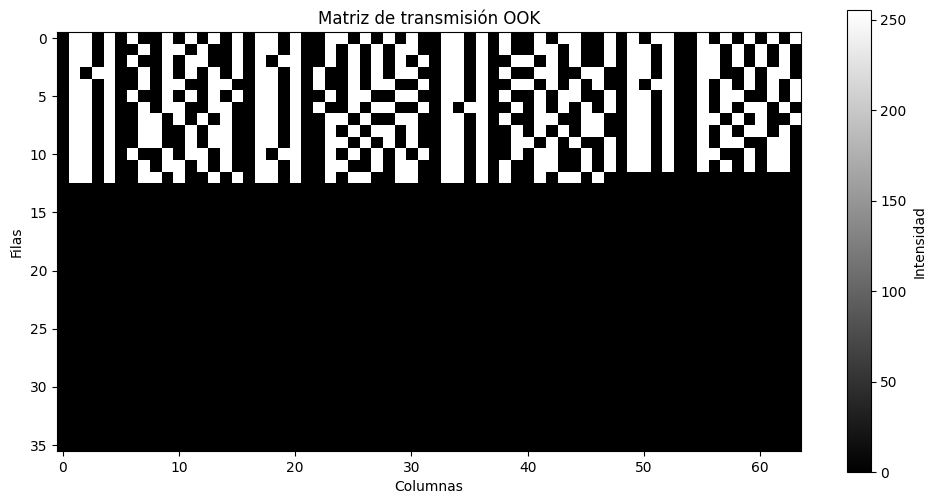

In [160]:
plt.figure(figsize=(12,6))

plt.imshow(matriz_tx, cmap="gray", vmin=0, vmax=255)

plt.title("Matriz de transmisión OOK")
plt.xlabel("Columnas")
plt.ylabel("Filas")

plt.colorbar(label="Intensidad")
plt.show()

### Generación del frame de transmisión

En esta etapa se convierte la matriz de símbolos en una imagen real.

Cada símbolo OOK de la matriz se expande a una celda cuadrada de 20 × 20 píxeles. De esta forma, la matriz de 36 × 64 celdas se transforma en una imagen de 720 × 1280 píxeles, lista para ser visualizada o guardada como frame de transmisión.

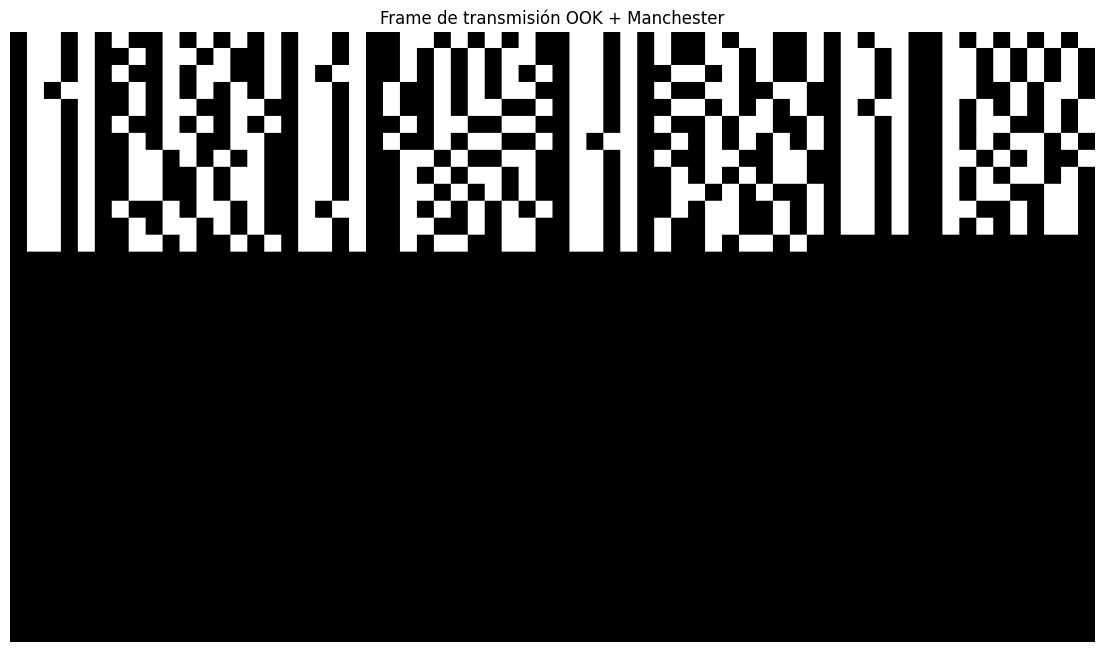

In [161]:
frame_tx = np.kron(
    matriz_tx,
    np.ones((tam_celda, tam_celda), dtype=np.uint8)
)

plt.figure(figsize=(14,8))

plt.imshow(frame_tx, cmap="gray", vmin=0, vmax=255)

plt.title("Frame de transmisión OOK + Manchester")
plt.axis("off")

plt.show()

### Integración del preámbulo y marcadores de orientación

Antes de codificar el mensaje se agrega una secuencia de preámbulo conocida. Esta secuencia se ubica al inicio de la trama y posteriormente se codifica junto con los bits del mensaje mediante codificación Manchester.

Su función principal es facilitar en el receptor la detección del inicio de la trama, la sincronización y la verificación del orden correcto de lectura de los datos.

Para esta implementación se utiliza un preámbulo asimétrico:

1110100011010110

Además, se incorpora un marcador fiducial especial en la esquina superior izquierda de la grilla. Este marcador es diferente a los otros tres marcadores de las esquinas y permite que el receptor identifique la orientación espacial correcta de la imagen capturada.

De esta forma, los marcadores fiduciales se utilizan para la localización de la pantalla, la estimación de la homografía y la corrección de perspectiva, mientras que el preámbulo permite validar que la trama fue leída en el orden adecuado antes de decodificar los datos útiles.

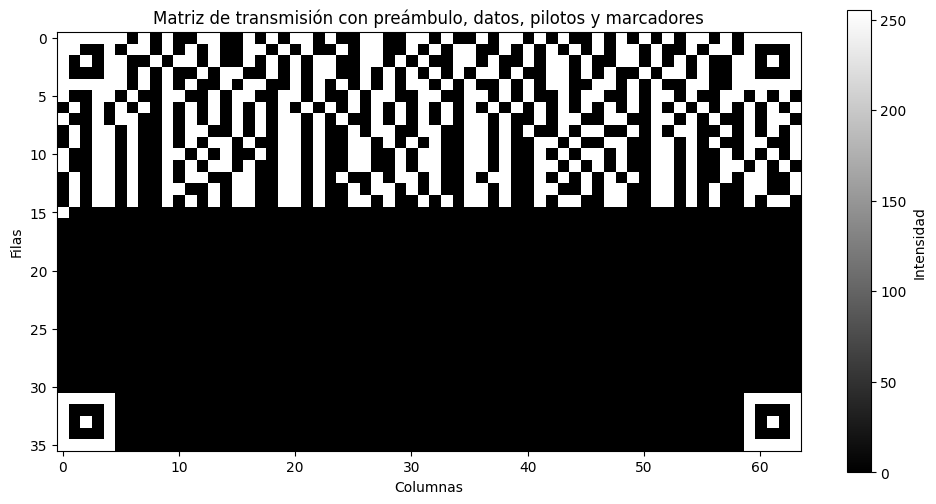

In [162]:
# ============================================================
# PREÁMBULO + MANCHESTER + OOK + MARCADORES + PILOTOS
# ============================================================

# Preámbulo asimétrico para sincronización y verificación de orientación
preambulo = "1110100011010110"

preambulo_array = np.array(
    [int(b) for b in preambulo],
    dtype=np.uint8
)

# Se agrega el preámbulo antes del mensaje útil
bits_tx = np.concatenate(
    [preambulo_array, bits_array]
)

# Codificación Manchester del preámbulo + mensaje
bits_manchester = codificar_manchester(bits_tx)

# Modulación OOK en escala de grises
nivel_bajo = 0
nivel_alto = 255

simbolos_ook = np.where(
    bits_manchester == 0,
    nivel_bajo,
    nivel_alto
).astype(np.uint8)


# ============================================================
# MARCADORES FIDUCIALES
# ============================================================

tam_marcador = 5  # marcador de 5x5 celdas

# Marcador normal tipo finder
marcador_normal = np.array([
    [255, 255, 255, 255, 255],
    [255,   0,   0,   0, 255],
    [255,   0, 255,   0, 255],
    [255,   0,   0,   0, 255],
    [255, 255, 255, 255, 255]
], dtype=np.uint8)

# Marcador especial para identificar la esquina superior izquierda
# Este marcador ayuda a resolver la orientación de la imagen en el receptor
marcador_orientacion = np.array([
    [255, 255, 255, 255, 255],
    [255, 255,   0,   0, 255],
    [255,   0, 255,   0, 255],
    [255,   0,   0,   0, 255],
    [255, 255, 255, 255, 255]
], dtype=np.uint8)


def insertar_marcadores(matriz):
    matriz = matriz.copy()

    # Superior izquierdo: marcador especial de orientación
    matriz[0:5, 0:5] = marcador_orientacion

    # Los otros tres marcadores son normales
    matriz[0:5, -5:] = marcador_normal          # Superior derecho
    matriz[-5:, 0:5] = marcador_normal          # Inferior izquierdo
    matriz[-5:, -5:] = marcador_normal          # Inferior derecho

    return matriz


# ============================================================
# PILOTOS
# ============================================================

def insertar_pilotos(matriz):
    matriz = matriz.copy()

    fila_pilotos = 6

    for col in range(num_columnas):
        if col % 2 == 0:
            matriz[fila_pilotos, col] = 0
        else:
            matriz[fila_pilotos, col] = 255

    return matriz


# ============================================================
# CREACIÓN DE LA MATRIZ DE TRANSMISIÓN
# ============================================================

matriz_tx = np.zeros(
    (num_filas, num_columnas),
    dtype=np.uint8
)

# Máscara para indicar dónde se pueden poner datos
mascara_datos = np.ones(
    (num_filas, num_columnas),
    dtype=bool
)

# Reservar espacio para los marcadores
mascara_datos[0:5, 0:5] = False
mascara_datos[0:5, -5:] = False
mascara_datos[-5:, 0:5] = False
mascara_datos[-5:, -5:] = False

# Reservar fila de pilotos
fila_pilotos = 6
mascara_datos[fila_pilotos, :] = False

# Posiciones disponibles para datos
posiciones_datos = np.argwhere(mascara_datos)

# Verificar capacidad de la grilla
if len(simbolos_ook) > len(posiciones_datos):
    raise ValueError(
        "El mensaje es demasiado largo para la grilla con marcadores y pilotos."
    )

# Insertar los símbolos OOK en las posiciones disponibles
for simbolo, (fila, columna) in zip(simbolos_ook, posiciones_datos):
    matriz_tx[fila, columna] = simbolo

# Insertar pilotos y marcadores
matriz_tx = insertar_pilotos(matriz_tx)
matriz_tx = insertar_marcadores(matriz_tx)


# ============================================================
# VISUALIZACIÓN
# ============================================================

plt.figure(figsize=(12, 6))

plt.imshow(
    matriz_tx,
    cmap="gray",
    vmin=0,
    vmax=255
)

plt.title("Matriz de transmisión con preámbulo, datos, pilotos y marcadores")
plt.xlabel("Columnas")
plt.ylabel("Filas")

plt.colorbar(label="Intensidad")
plt.show()

In [163]:
frame_tx = np.kron(
    matriz_tx,
    np.ones((tam_celda, tam_celda), dtype=np.uint8)
)

plt.imsave(
    "frame_tx_ook_manchester_completo.png",
    frame_tx,
    cmap="gray",
    vmin=0,
    vmax=255
)

print("Frame guardado como: frame_tx_ook_manchester_completo.png")


Frame guardado como: frame_tx_ook_manchester_completo.png


### Decodificador ideal del frame

En esta etapa se verifica el lazo digital de extremo a extremo usando la imagen generada previamente.

El decodificador ideal lee el frame `.png`, lo divide nuevamente en celdas de 20 × 20 píxeles, calcula la intensidad promedio de cada celda y recupera los símbolos OOK.

Posteriormente se eliminan las posiciones reservadas para marcadores y pilotos, se decodifica Manchester, se retira el preámbulo y se reconstruye el mensaje ASCII original.

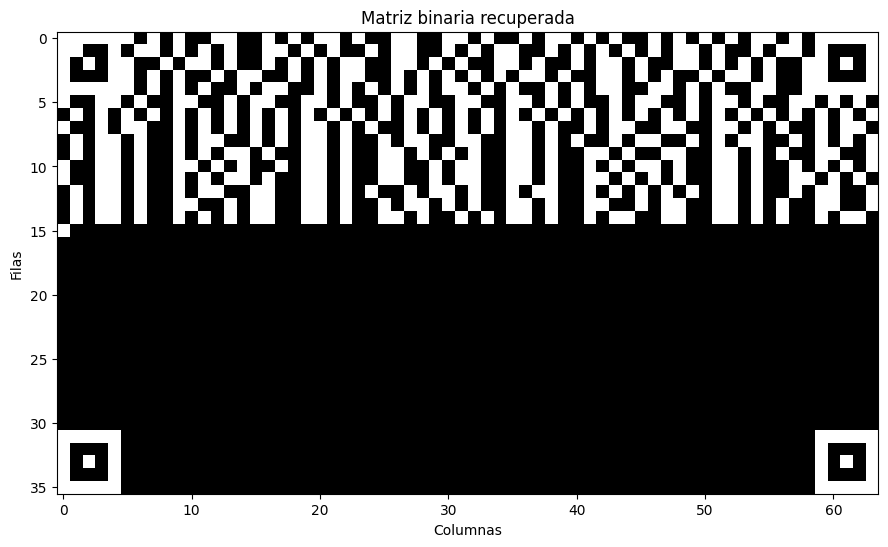

In [164]:
ruta_frame = "frame_tx_ook_manchester_completo.png"

img_rx = cv2.imread(ruta_frame, cv2.IMREAD_GRAYSCALE)

if img_rx is None:
    raise FileNotFoundError("No se pudo leer la imagen. Verifica la ruta del archivo.")

ancho_img = 1280
alto_img = 720
tam_celda = 20

num_columnas = ancho_img // tam_celda
num_filas = alto_img // tam_celda

matriz_rx = np.zeros((num_filas, num_columnas), dtype=np.float32)

for fila in range(num_filas):
    for col in range(num_columnas):

        y0 = fila * tam_celda
        y1 = y0 + tam_celda

        x0 = col * tam_celda
        x1 = x0 + tam_celda

        celda = img_rx[y0:y1, x0:x1]

        matriz_rx[fila, col] = np.mean(celda)

umbral = 127

matriz_bits_rx = (matriz_rx > umbral).astype(np.uint8)

plt.figure(figsize=(12,6))
plt.imshow(matriz_bits_rx, cmap="gray", vmin=0, vmax=1)
plt.title("Matriz binaria recuperada")
plt.xlabel("Columnas")
plt.ylabel("Filas")
plt.show()

In [165]:
mascara_datos = np.ones((num_filas, num_columnas), dtype=bool)

mascara_datos[0:5, 0:5] = False
mascara_datos[0:5, -5:] = False
mascara_datos[-5:, 0:5] = False
mascara_datos[-5:, -5:] = False

fila_pilotos = 6
mascara_datos[fila_pilotos, :] = False

bits_manchester_rx = matriz_bits_rx[mascara_datos]

bits_manchester_rx = bits_manchester_rx[:len(simbolos_ook)]

def decodificar_manchester(bits_manchester):
    bits_decodificados = []

    if len(bits_manchester) % 2 != 0:
        raise ValueError("La secuencia Manchester debe tener longitud par.")

    for i in range(0, len(bits_manchester), 2):
        par = bits_manchester[i:i+2]

        if np.array_equal(par, [0, 1]):
            bits_decodificados.append(0)
        elif np.array_equal(par, [1, 0]):
            bits_decodificados.append(1)
        else:
            # Par inválido: 00 o 11
            bits_decodificados.append(-1)

    return np.array(bits_decodificados)


bits_rx = decodificar_manchester(bits_manchester_rx)

errores_manchester = np.sum(bits_rx == -1)
print("Errores Manchester:", errores_manchester)

Errores Manchester: 0


### Constelación de píxeles (niveles de intensidad)

Se analiza la intensidad promedio medida en cada celda de datos del frame recibido.

En OOK ideal se espera observar dos agrupaciones principales:

- valores cercanos a negro (bit 0)
- valores cercanos a blanco (bit 1)

Esta distribución permite verificar la separación entre símbolos antes de aplicar el umbral de decisión.

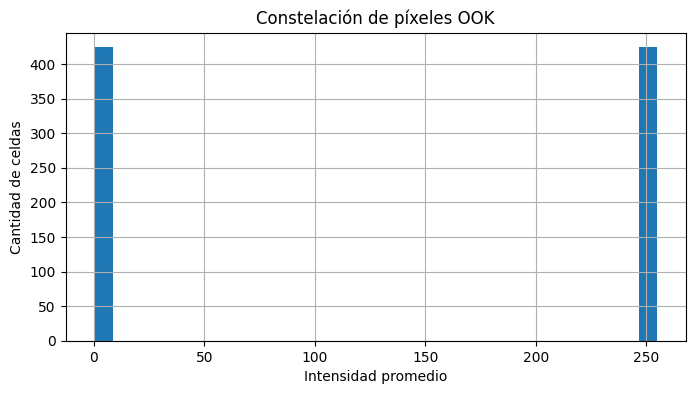

In [166]:
# Intensidades medidas solo en datos
intensidades_rx = matriz_rx[mascara_datos]

# recortar solo símbolos transmitidos
intensidades_rx = intensidades_rx[:len(simbolos_ook)]

plt.figure(figsize=(8,4))

plt.hist(
    intensidades_rx,
    bins=30
)

plt.xlabel("Intensidad promedio")
plt.ylabel("Cantidad de celdas")

plt.title("Constelación de píxeles OOK")

plt.grid(True)

plt.show()

### Reconstrucción del Mensaje

In [167]:
preambulo = "1010101011110000"
len_preambulo = len(preambulo)

preambulo_rx = bits_rx[:len_preambulo]
datos_rx = bits_rx[len_preambulo:]

print("Preámbulo recibido:")
print(preambulo_rx)

print("Preámbulo esperado:")
print(np.array([int(b) for b in preambulo]))


datos_rx = datos_rx[datos_rx != -1]

num_bits_validos = (len(datos_rx) // 8) * 8
datos_rx = datos_rx[:num_bits_validos]

caracteres = []

for i in range(0, len(datos_rx), 8):
    byte = datos_rx[i:i+8]

    valor_ascii = int("".join(str(b) for b in byte), 2)

    if valor_ascii == 0:
        break

    caracteres.append(chr(valor_ascii))

mensaje_rx = "".join(caracteres)

print("\nMensaje recuperado:")
print(mensaje_rx)

Preámbulo recibido:
[1 1 1 0 1 0 0 0 1 1 0 1 0 1 1 0]
Preámbulo esperado:
[1 0 1 0 1 0 1 0 1 1 1 1 0 0 0 0]

Mensaje recuperado:
por favor no quiero perder comunicaciones digitales


# Fase B
## Deteccion de ROI y registro geometrico
En esta primera parte del receptor se busca pasar de una imagen capturada por la camara a una grilla comparable con la transmitida. Para lograrlo se localiza la region de interes usando los marcadores fiduciales de las esquinas, se estima una homografia y se rectifica la pantalla a una vista cenital.

La celda queda preparada para dos escenarios: si ya existe una captura real, se usa directamente; si todavia no hay imagen de camara, se genera una captura sintetica con perspectiva a partir del frame transmitido para validar el flujo completo.

In [168]:
# ============================================================
# FASE B.1 - FUNCIONES DE ROI, HOMOGRAFIA Y RECTIFICACION
# ============================================================

# Valores por defecto por si esta seccion se ejecuta despues de reiniciar el kernel
if "ancho_img" not in globals():
    ancho_img = 1280

if "alto_img" not in globals():
    alto_img = 720

if "tam_celda" not in globals():
    tam_celda = 20

if "tam_marcador" not in globals():
    tam_marcador = 5

if "marcador_normal" not in globals():
    marcador_normal = np.array([
        [255, 255, 255, 255, 255],
        [255,   0,   0,   0, 255],
        [255,   0, 255,   0, 255],
        [255,   0,   0,   0, 255],
        [255, 255, 255, 255, 255]
    ], dtype=np.uint8)

if "marcador_orientacion" not in globals():
    marcador_orientacion = np.array([
        [255, 255, 255, 255, 255],
        [255, 255,   0,   0, 255],
        [255,   0, 255,   0, 255],
        [255,   0,   0,   0, 255],
        [255, 255, 255, 255, 255]
    ], dtype=np.uint8)


def mostrar_gris(img, titulo, figsize=(8, 5)):
    plt.figure(figsize=figsize)
    plt.imshow(img, cmap="gray", vmin=0, vmax=255)
    plt.title(titulo)
    plt.axis("off")
    plt.show()


def ordenar_puntos_cuadrilatero(puntos):
    puntos = np.asarray(puntos, dtype=np.float32).reshape(4, 2)

    suma = puntos.sum(axis=1)
    diferencia = np.diff(puntos, axis=1).reshape(-1)

    ordenados = np.zeros((4, 2), dtype=np.float32)
    ordenados[0] = puntos[np.argmin(suma)]        # superior izquierda
    ordenados[2] = puntos[np.argmax(suma)]        # inferior derecha
    ordenados[1] = puntos[np.argmin(diferencia)]  # superior derecha
    ordenados[3] = puntos[np.argmax(diferencia)]  # inferior izquierda

    return ordenados


def detectar_cuadrilatero_roi(img_gris):
    suavizada = cv2.GaussianBlur(img_gris, (5, 5), 0)
    _, mascara = cv2.threshold(
        suavizada,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    # Se conservan componentes brillantes suficientemente grandes.
    # Los marcadores en las esquinas hacen que la envolvente convexa aproxime la pantalla.
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mascara, connectivity=8)
    mascara_filtrada = np.zeros_like(mascara)
    area_minima = max(25, int(0.00002 * img_gris.shape[0] * img_gris.shape[1]))

    for etiqueta in range(1, num_labels):
        if stats[etiqueta, cv2.CC_STAT_AREA] >= area_minima:
            mascara_filtrada[labels == etiqueta] = 255

    puntos = cv2.findNonZero(mascara_filtrada)

    if puntos is None or len(puntos) < 4:
        raise ValueError("No se encontraron suficientes puntos brillantes para localizar la ROI.")

    hull = cv2.convexHull(puntos)
    perimetro = cv2.arcLength(hull, True)

    cuadrilatero = None

    for epsilon in np.linspace(0.005, 0.04, 8):
        aproximado = cv2.approxPolyDP(hull, epsilon * perimetro, True)
        if len(aproximado) == 4:
            cuadrilatero = aproximado.reshape(4, 2)
            break

    if cuadrilatero is None:
        rect = cv2.minAreaRect(hull)
        cuadrilatero = cv2.boxPoints(rect)

    return ordenar_puntos_cuadrilatero(cuadrilatero), mascara_filtrada


def extraer_marcador(rectificada, esquina):
    lado = tam_marcador * tam_celda

    if esquina == "sup_izq":
        parche = rectificada[0:lado, 0:lado]
    elif esquina == "sup_der":
        parche = rectificada[0:lado, -lado:]
    elif esquina == "inf_der":
        parche = rectificada[-lado:, -lado:]
    elif esquina == "inf_izq":
        parche = rectificada[-lado:, 0:lado]
    else:
        raise ValueError("Esquina no reconocida.")

    promedios = np.zeros((tam_marcador, tam_marcador), dtype=np.float32)

    for fila in range(tam_marcador):
        for columna in range(tam_marcador):
            y0 = fila * tam_celda
            y1 = (fila + 1) * tam_celda
            x0 = columna * tam_celda
            x1 = (columna + 1) * tam_celda
            promedios[fila, columna] = np.mean(parche[y0:y1, x0:x1])

    umbral = (np.min(promedios) + np.max(promedios)) / 2
    return np.where(promedios >= umbral, 255, 0).astype(np.uint8)


def distancia_patron(medido, esperado):
    return np.mean(medido != esperado)


def puntuar_orientacion(rectificada):
    esquinas = ["sup_izq", "sup_der", "inf_der", "inf_izq"]
    puntaje = 0
    marcadores_muestreados = {}

    for esquina in esquinas:
        medido = extraer_marcador(rectificada, esquina)
        marcadores_muestreados[esquina] = medido

        if esquina == "sup_izq":
            puntaje += distancia_patron(medido, marcador_orientacion)
        else:
            puntaje += distancia_patron(medido, marcador_normal)

    return puntaje, marcadores_muestreados


def rectificar_con_orientacion(img_gris, esquinas_roi):
    destino = np.float32([
        [0, 0],
        [ancho_img - 1, 0],
        [ancho_img - 1, alto_img - 1],
        [0, alto_img - 1]
    ])

    mejor = None

    # Se prueban las cuatro posibles esquinas iniciales. La correcta es la que deja
    # el marcador especial en la esquina superior izquierda del frame rectificado.
    for desplazamiento in range(4):
        fuente = np.roll(esquinas_roi, -desplazamiento, axis=0).astype(np.float32)
        H = cv2.getPerspectiveTransform(fuente, destino)
        rectificada = cv2.warpPerspective(
            img_gris,
            H,
            (ancho_img, alto_img),
            flags=cv2.INTER_LINEAR
        )

        puntaje, marcadores_muestreados = puntuar_orientacion(rectificada)

        if mejor is None or puntaje < mejor["puntaje"]:
            mejor = {
                "desplazamiento": desplazamiento,
                "fuente": fuente,
                "H": H,
                "rectificada": rectificada,
                "puntaje": puntaje,
                "marcadores": marcadores_muestreados
            }

    return mejor


def dibujar_roi(img_gris, esquinas_roi):
    vista = cv2.cvtColor(img_gris, cv2.COLOR_GRAY2RGB)
    puntos = esquinas_roi.astype(int)

    for i in range(4):
        p0 = tuple(puntos[i])
        p1 = tuple(puntos[(i + 1) % 4])
        cv2.line(vista, p0, p1, (0, 255, 0), 3)
        cv2.circle(vista, p0, 7, (255, 0, 0), -1)

    return vista

## Prueba de entrada para el receptor

Para mantener la Fase B como una prueba reproducible, esta entrada usa una imagen generada por el propio proyecto. Se toma el frame transmitido, se le aplica una homografia sintetica y se procesa como si fuera una captura de camara. La prueba con camara real queda en una seccion independiente al final de la Fase B.

Se genero una captura sintetica para probar la Fase B.


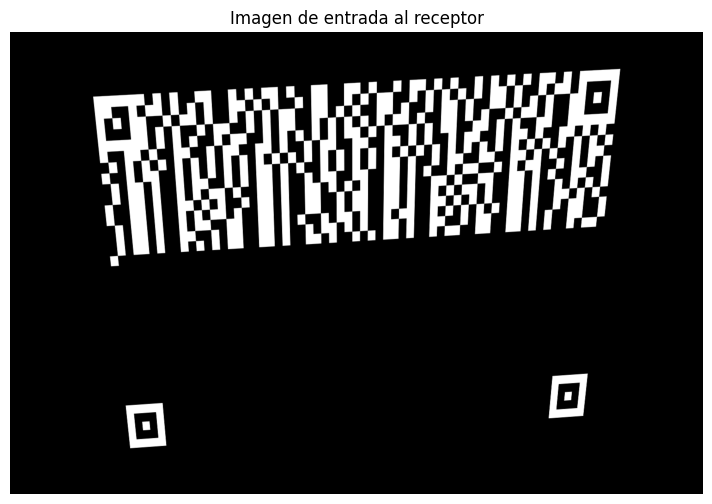

In [169]:
# ============================================================
# ENTRADA SINTETICA PARA FASE B
# ============================================================

# Frame base generado por la Fase A. Puedes cambiar esta ruta si quieres
# probar otro frame generado, pero esta celda no abre la camara.
RUTA_FRAME_SINTETICO = "frame_tx_ook_manchester_completo.png"

if "frame_tx" not in globals():
    frame_tx = cv2.imread(RUTA_FRAME_SINTETICO, cv2.IMREAD_GRAYSCALE)

if frame_tx is None:
    raise FileNotFoundError(
        "No se encontro el frame transmitido de referencia: " + RUTA_FRAME_SINTETICO
    )

alto_canvas = 1000
ancho_canvas = 1500

puntos_frame = np.float32([
    [0, 0],
    [ancho_img - 1, 0],
    [ancho_img - 1, alto_img - 1],
    [0, alto_img - 1]
])

puntos_camara = np.float32([
    [180, 140],
    [1320, 80],
    [1240, 830],
    [260, 900]
])

H_sintetica = cv2.getPerspectiveTransform(puntos_frame, puntos_camara)
img_capturada = cv2.warpPerspective(
    frame_tx,
    H_sintetica,
    (ancho_canvas, alto_canvas),
    borderValue=0
)

print("Se genero una captura sintetica para probar la Fase B.")
mostrar_gris(img_capturada, "Imagen de entrada al receptor", figsize=(10, 6))

### Localizacion de ROI y rectificacion

Con la imagen de entrada se umbralizan las regiones brillantes, se obtiene la envolvente convexa asociada a la pantalla y se aproxima un cuadrilatero. Luego se prueban las cuatro correspondencias posibles entre las esquinas detectadas y las esquinas del frame ideal; se conserva la homografia que deja el marcador especial de orientacion en la esquina superior izquierda.

Esquinas detectadas de la ROI:
[[ 180.  140.]
 [1320.   81.]
 [1239.  830.]
 [ 260.  899.]]

Desplazamiento seleccionado: 0
Puntaje de marcadores: 0.0

Homografia estimada:
[[ 1.05105719e+00 -1.10783366e-01 -1.73680623e+02]
 [ 4.04934338e-02  7.82415500e-01 -1.16826988e+02]
 [-3.29972049e-05 -1.79056413e-04  1.00000000e+00]]


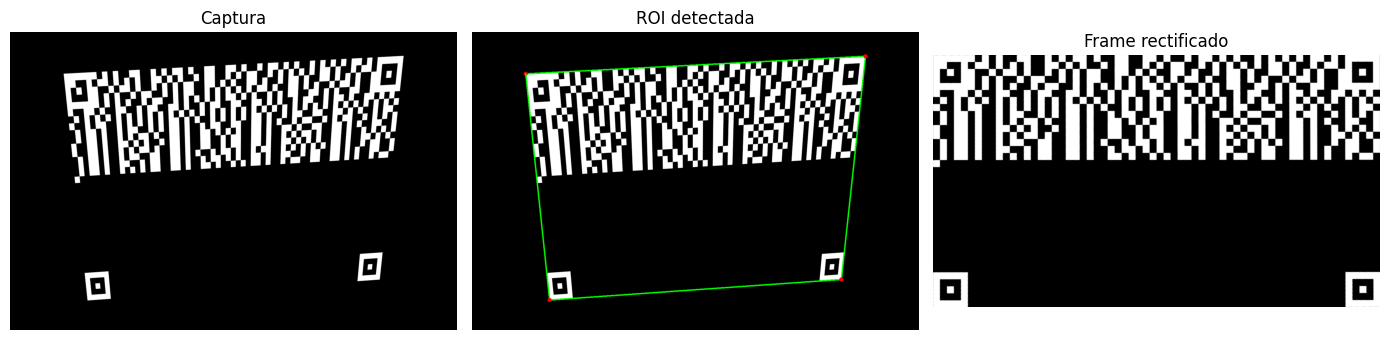

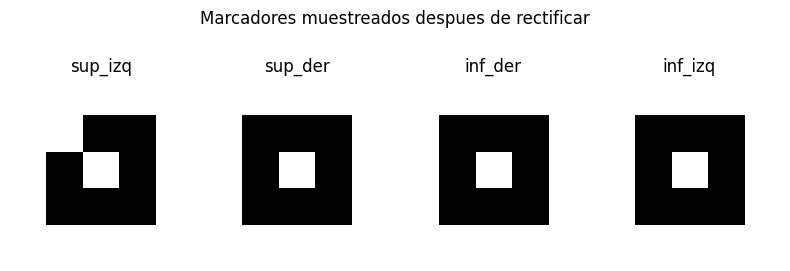

In [170]:
esquinas_roi, mascara_roi = detectar_cuadrilatero_roi(img_capturada)
resultado_rectificacion = rectificar_con_orientacion(img_capturada, esquinas_roi)
frame_rectificado = resultado_rectificacion["rectificada"]
H_roi = resultado_rectificacion["H"]

print("Esquinas detectadas de la ROI:")
print(esquinas_roi)

print("\nDesplazamiento seleccionado:", resultado_rectificacion["desplazamiento"])
print("Puntaje de marcadores:", resultado_rectificacion["puntaje"])
print("\nHomografia estimada:")
print(H_roi)

plt.figure(figsize=(14, 8))

plt.subplot(1, 3, 1)
plt.imshow(img_capturada, cmap="gray", vmin=0, vmax=255)
plt.title("Captura")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(dibujar_roi(img_capturada, esquinas_roi))
plt.title("ROI detectada")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(frame_rectificado, cmap="gray", vmin=0, vmax=255)
plt.title("Frame rectificado")
plt.axis("off")

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 3))
for i, (esquina, marcador) in enumerate(resultado_rectificacion["marcadores"].items(), start=1):
    plt.subplot(1, 4, i)
    plt.imshow(marcador, cmap="gray", vmin=0, vmax=255)
    plt.title(esquina)
    plt.axis("off")

plt.suptitle("Marcadores muestreados despues de rectificar")
plt.tight_layout()
plt.show()

## Calibracion de color/brillo y AGC

Despues de rectificar geometricamente el frame, el siguiente problema es que los valores de intensidad ya no necesariamente corresponden a negro ideal y blanco ideal. La iluminacion ambiente, la exposicion automatica de la camara y la respuesta de la pantalla pueden cambiar el brillo y el contraste de forma lenta sobre la imagen.

Para compensarlo se usan las celdas conocidas: la fila de pilotos alternados y los marcadores fiduciales. Con esas muestras se estima un nivel negro local y un nivel blanco local. Luego se aplica un control automatico de ganancia (AGC) por software antes de tomar la decision binaria.

In [171]:
# ============================================================
# FASE B.2 - CALIBRACION DE BRILLO/COLOR Y AGC
# ============================================================

if "num_filas" not in globals():
    num_filas = alto_img // tam_celda

if "num_columnas" not in globals():
    num_columnas = ancho_img // tam_celda

if "fila_pilotos" not in globals():
    fila_pilotos = 6


def convertir_a_luminancia(img):
    if img.ndim == 2:
        return img.astype(np.float32)

    # OpenCV carga imagenes en BGR. Si se trabaja con una captura a color,
    # esta luminancia reduce el efecto de matiz antes de decidir OOK.
    b, g, r = cv2.split(img.astype(np.float32))
    return 0.114 * b + 0.587 * g + 0.299 * r


def corregir_balance_blancos_gray_world(img_bgr):
    if img_bgr.ndim != 3:
        return img_bgr

    img_float = img_bgr.astype(np.float32)
    promedios = np.mean(img_float.reshape(-1, 3), axis=0)
    promedio_global = np.mean(promedios)
    ganancias = promedio_global / np.maximum(promedios, 1e-6)
    corregida = img_float * ganancias.reshape(1, 1, 3)

    return np.clip(corregida, 0, 255).astype(np.uint8)


def promediar_celdas(img_rectificada, margen_relativo=0.20):
    luminancia = convertir_a_luminancia(img_rectificada)
    promedios = np.zeros((num_filas, num_columnas), dtype=np.float32)

    margen = int(round(tam_celda * margen_relativo))

    for fila in range(num_filas):
        for columna in range(num_columnas):
            y0 = fila * tam_celda + margen
            y1 = (fila + 1) * tam_celda - margen
            x0 = columna * tam_celda + margen
            x1 = (columna + 1) * tam_celda - margen

            celda = luminancia[y0:y1, x0:x1]
            promedios[fila, columna] = np.mean(celda)

    return promedios


def construir_referencia_celdas_conocidas():
    referencia = np.full((num_filas, num_columnas), np.nan, dtype=np.float32)

    for columna in range(num_columnas):
        referencia[fila_pilotos, columna] = 0 if columna % 2 == 0 else 1

    marcadores = [
        (0, 0, marcador_orientacion),
        (0, num_columnas - tam_marcador, marcador_normal),
        (num_filas - tam_marcador, 0, marcador_normal),
        (num_filas - tam_marcador, num_columnas - tam_marcador, marcador_normal),
    ]

    for fila0, columna0, patron in marcadores:
        patron_binario = (patron > 127).astype(np.float32)
        referencia[
            fila0:fila0 + tam_marcador,
            columna0:columna0 + tam_marcador
        ] = patron_binario

    return referencia


def base_polinomial(filas, columnas):
    y = filas / max(num_filas - 1, 1)
    x = columnas / max(num_columnas - 1, 1)

    return np.column_stack([
        np.ones_like(x),
        x,
        y,
        x * y,
        x ** 2,
        y ** 2
    ])


def ajustar_mapa_lento(coords, valores):
    if len(valores) < 6:
        return np.full((num_filas, num_columnas), np.median(valores), dtype=np.float32)

    filas = coords[:, 0].astype(np.float32)
    columnas = coords[:, 1].astype(np.float32)
    A = base_polinomial(filas, columnas)
    coeficientes, *_ = np.linalg.lstsq(A, valores.astype(np.float32), rcond=None)

    grid_filas, grid_columnas = np.indices((num_filas, num_columnas), dtype=np.float32)
    A_grid = base_polinomial(grid_filas.ravel(), grid_columnas.ravel())
    mapa = A_grid @ coeficientes

    return mapa.reshape(num_filas, num_columnas).astype(np.float32)


def calibrar_agc_celdas(promedios_celdas, contraste_minimo=20):
    referencia = construir_referencia_celdas_conocidas()

    coords_negro = np.argwhere(referencia == 0)
    coords_blanco = np.argwhere(referencia == 1)

    muestras_negro = promedios_celdas[referencia == 0]
    muestras_blanco = promedios_celdas[referencia == 1]

    mapa_negro = ajustar_mapa_lento(coords_negro, muestras_negro)
    mapa_blanco = ajustar_mapa_lento(coords_blanco, muestras_blanco)

    # Evita divisiones inestables cuando una zona queda con poco contraste.
    mapa_blanco = np.maximum(mapa_blanco, mapa_negro + contraste_minimo)
    mapa_umbral = 0.5 * (mapa_negro + mapa_blanco)

    normalizada = (promedios_celdas - mapa_negro) / (mapa_blanco - mapa_negro)
    normalizada = np.clip(normalizada, 0, 1)

    bits_decididos = (normalizada >= 0.5).astype(np.uint8)

    return {
        "referencia": referencia,
        "mapa_negro": mapa_negro,
        "mapa_blanco": mapa_blanco,
        "mapa_umbral": mapa_umbral,
        "normalizada": normalizada,
        "bits": bits_decididos,
        "muestras_negro": muestras_negro,
        "muestras_blanco": muestras_blanco,
    }


def reconstruir_frame_desde_celdas(matriz_celdas):
    matriz_uint8 = np.clip(255 * matriz_celdas, 0, 255).astype(np.uint8)
    return np.kron(
        matriz_uint8,
        np.ones((tam_celda, tam_celda), dtype=np.uint8)
    )

### Aplicacion del AGC

Primero se promedia cada celda rectificada usando solo la zona central para reducir errores de borde. Despues se ajustan mapas suaves de negro y blanco con las celdas conocidas. El umbral deja de ser un numero fijo global y pasa a ser una superficie adaptativa: cada celda se compara contra el nivel esperado en su ubicacion.

Promedio de muestras negras conocidas: 0.0
Promedio de muestras blancas conocidas: 255.0
Contraste medio estimado: 255.0
Rango despues de AGC: 0.0 a 1.0


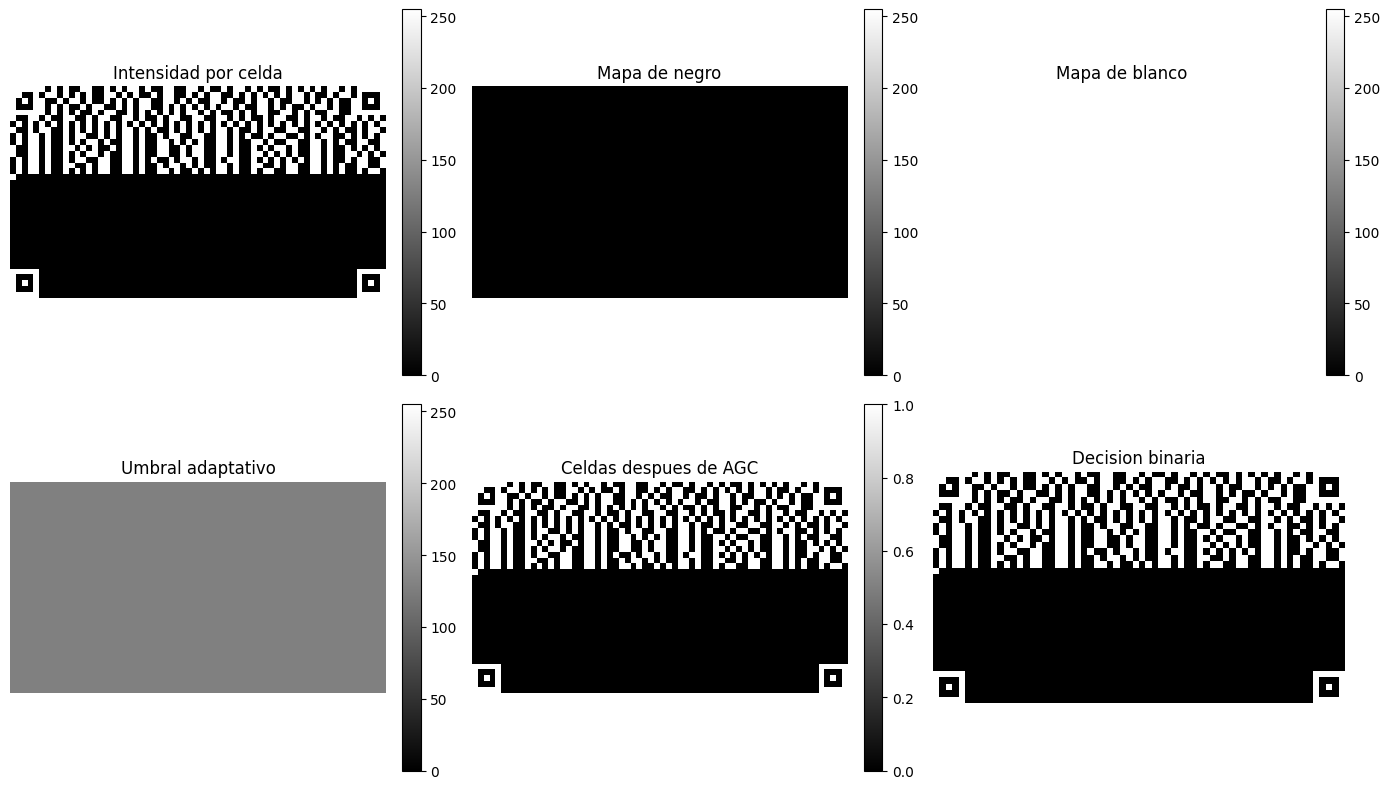

In [172]:
matriz_intensidad_rx = promediar_celdas(frame_rectificado)
resultado_agc = calibrar_agc_celdas(matriz_intensidad_rx)

matriz_rx_agc = resultado_agc["normalizada"]
bits_rx_agc = resultado_agc["bits"]
umbral_adaptativo = resultado_agc["mapa_umbral"]
frame_rectificado_agc = reconstruir_frame_desde_celdas(matriz_rx_agc)

print("Promedio de muestras negras conocidas:", np.mean(resultado_agc["muestras_negro"]))
print("Promedio de muestras blancas conocidas:", np.mean(resultado_agc["muestras_blanco"]))
print("Contraste medio estimado:", np.mean(resultado_agc["mapa_blanco"] - resultado_agc["mapa_negro"]))
print("Rango despues de AGC:", np.min(matriz_rx_agc), "a", np.max(matriz_rx_agc))

plt.figure(figsize=(14, 8))

plt.subplot(2, 3, 1)
plt.imshow(matriz_intensidad_rx, cmap="gray", vmin=0, vmax=255)
plt.title("Intensidad por celda")
plt.axis("off")
plt.colorbar(fraction=0.046, pad=0.04)

plt.subplot(2, 3, 2)
plt.imshow(resultado_agc["mapa_negro"], cmap="gray", vmin=0, vmax=255)
plt.title("Mapa de negro")
plt.axis("off")
plt.colorbar(fraction=0.046, pad=0.04)

plt.subplot(2, 3, 3)
plt.imshow(resultado_agc["mapa_blanco"], cmap="gray", vmin=0, vmax=255)
plt.title("Mapa de blanco")
plt.axis("off")
plt.colorbar(fraction=0.046, pad=0.04)

plt.subplot(2, 3, 4)
plt.imshow(umbral_adaptativo, cmap="gray", vmin=0, vmax=255)
plt.title("Umbral adaptativo")
plt.axis("off")
plt.colorbar(fraction=0.046, pad=0.04)

plt.subplot(2, 3, 5)
plt.imshow(matriz_rx_agc, cmap="gray", vmin=0, vmax=1)
plt.title("Celdas despues de AGC")
plt.axis("off")
plt.colorbar(fraction=0.046, pad=0.04)

plt.subplot(2, 3, 6)
plt.imshow(bits_rx_agc, cmap="gray", vmin=0, vmax=1)
plt.title("Decision binaria")
plt.axis("off")

plt.tight_layout()
plt.show()

### Comparacion de umbrales

La grafica permite ver por que el AGC ayuda: antes de normalizar, las muestras pueden desplazarse por brillo o contraste; despues de normalizar, el decisor puede trabajar alrededor de `0.5` aunque la iluminacion cambie lentamente sobre la pantalla.

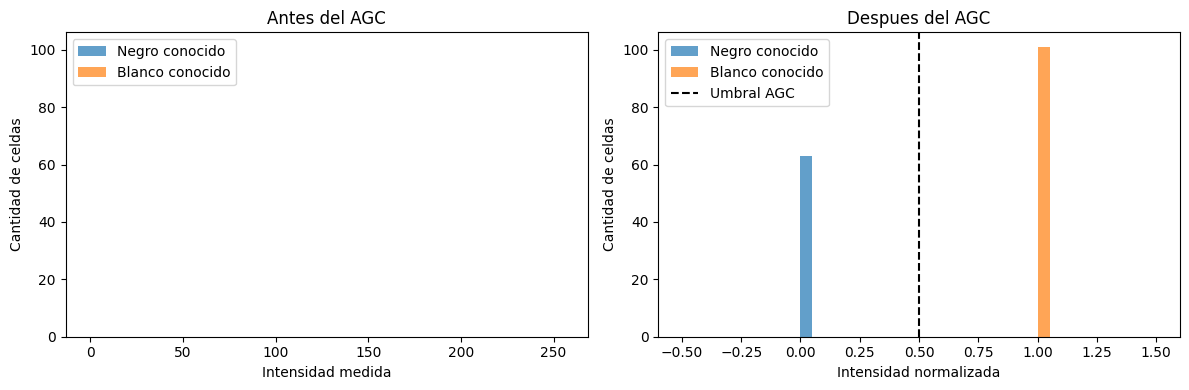

In [173]:
referencia_conocida = resultado_agc["referencia"]
mascara_conocida = ~np.isnan(referencia_conocida)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(
    matriz_intensidad_rx[mascara_conocida & (referencia_conocida == 0)],
    bins=20,
    alpha=0.7,
    label="Negro conocido"
)
plt.hist(
    matriz_intensidad_rx[mascara_conocida & (referencia_conocida == 1)],
    bins=20,
    alpha=0.7,
    label="Blanco conocido"
)
plt.title("Antes del AGC")
plt.xlabel("Intensidad medida")
plt.ylabel("Cantidad de celdas")
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(
    matriz_rx_agc[mascara_conocida & (referencia_conocida == 0)],
    bins=20,
    alpha=0.7,
    label="Negro conocido"
)
plt.hist(
    matriz_rx_agc[mascara_conocida & (referencia_conocida == 1)],
    bins=20,
    alpha=0.7,
    label="Blanco conocido"
)
plt.axvline(0.5, color="k", linestyle="--", label="Umbral AGC")
plt.title("Despues del AGC")
plt.xlabel("Intensidad normalizada")
plt.ylabel("Cantidad de celdas")
plt.legend()

plt.tight_layout()
plt.show()

## Sincronizacion temporal, reloj de simbolo y preambulo

En esta etapa se ordenan temporalmente las muestras antes de decodificar. En una camara con rolling shutter, las filas de la imagen no se capturan al mismo tiempo: una celda ubicada más abajo representa una muestra ligeramente posterior a una celda ubicada arriba. Por eso se dejan funciones para estimar y compensar retardos por fila para cuando se trabaje con una secuencia temporal de capturas.

Con el frame rectificado y calibrado se extrae la secuencia de celdas de datos, se recupera el reloj de simbolo sobre una versión interpolada de la señal de intensidad y se sincroniza la trama buscando el preambulo Manchester definido en la Fase A.

In [174]:
# ============================================================
# FASE B.3 - ROLLING SHUTTER, RELOJ DE SIMBOLO Y PREAMBULO
# ============================================================

def construir_mascara_datos_receptor():
    mascara = np.ones((num_filas, num_columnas), dtype=bool)

    mascara[0:tam_marcador, 0:tam_marcador] = False
    mascara[0:tam_marcador, -tam_marcador:] = False
    mascara[-tam_marcador:, 0:tam_marcador] = False
    mascara[-tam_marcador:, -tam_marcador:] = False
    mascara[fila_pilotos, :] = False

    return mascara


def extraer_senal_datos(matriz_celdas):
    mascara = construir_mascara_datos_receptor()
    posiciones = np.argwhere(mascara)
    senal = matriz_celdas[mascara].astype(np.float32)

    return senal, posiciones, mascara


def interpolar_1d(senal, t):
    eje = np.arange(len(senal), dtype=np.float32)
    return np.interp(t, eje, senal, left=senal[0], right=senal[-1])


def estimar_retardos_enteros_por_fila(secuencia_por_fila, fila_referencia=0, max_lag=20):
    # Entrada esperada: arreglo [tiempo, fila] con una senal piloto por fila.
    # Devuelve el retardo de cada fila en muestras respecto a la fila de referencia.
    secuencia = np.asarray(secuencia_por_fila, dtype=np.float32)
    referencia = secuencia[:, fila_referencia] - np.mean(secuencia[:, fila_referencia])
    retardos = np.zeros(secuencia.shape[1], dtype=np.int32)

    for fila in range(secuencia.shape[1]):
        actual = secuencia[:, fila] - np.mean(secuencia[:, fila])
        correlaciones = []
        lags = np.arange(-max_lag, max_lag + 1)

        for lag in lags:
            if lag < 0:
                a = actual[-lag:]
                b = referencia[:len(a)]
            elif lag > 0:
                a = actual[:-lag]
                b = referencia[lag:]
            else:
                a = actual
                b = referencia

            correlaciones.append(np.sum(a * b))

        retardos[fila] = lags[np.argmax(correlaciones)]

    return retardos


def compensar_rolling_shutter(secuencia_frames, retardo_por_fila_simbolos=0.0):
    # Entrada esperada: [tiempo, fila, columna].
    # Con un solo frame espacial no hay eje temporal suficiente para compensar;
    # en ese caso se retorna una copia sin modificar.
    secuencia = np.asarray(secuencia_frames, dtype=np.float32)

    if secuencia.ndim != 3 or secuencia.shape[0] < 2:
        return secuencia.copy()

    num_tiempos, filas, columnas = secuencia.shape
    eje_t = np.arange(num_tiempos, dtype=np.float32)
    corregida = np.zeros_like(secuencia)

    for fila in range(filas):
        retardo = fila * retardo_por_fila_simbolos
        t_compensado = eje_t + retardo

        for columna in range(columnas):
            corregida[:, fila, columna] = np.interp(
                t_compensado,
                eje_t,
                secuencia[:, fila, columna],
                left=secuencia[0, fila, columna],
                right=secuencia[-1, fila, columna]
            )

    return corregida


def sobremuestrear_senal(senal_simbolos, muestras_por_simbolo=8, desfase=0.0):
    senal = np.asarray(senal_simbolos, dtype=np.float32)
    t = (np.arange(len(senal) * muestras_por_simbolo, dtype=np.float32) + desfase)
    t = t / muestras_por_simbolo

    return interpolar_1d(senal, t)


def recuperar_reloj_early_late(senal_sobremuestreada, muestras_por_simbolo=8, mu_inicial=None, ganancia=0.05):
    senal = np.asarray(senal_sobremuestreada, dtype=np.float32)

    if mu_inicial is None:
        mu = muestras_por_simbolo / 2
    else:
        mu = float(mu_inicial)

    mitad = muestras_por_simbolo / 2
    muestras = []
    tiempos = []
    errores = []

    while mu + mitad < len(senal) - 1:
        temprano = interpolar_1d(senal, mu - mitad)
        centro = interpolar_1d(senal, mu)
        tarde = interpolar_1d(senal, mu + mitad)

        # Error early-late dirigido por dato: se activa con transiciones y
        # corrige lentamente el instante de muestreo.
        error = (tarde - temprano) * (centro - 0.5)

        muestras.append(centro)
        tiempos.append(mu)
        errores.append(error)

        mu += muestras_por_simbolo - ganancia * error

    return {
        "muestras": np.asarray(muestras, dtype=np.float32),
        "tiempos": np.asarray(tiempos, dtype=np.float32),
        "errores": np.asarray(errores, dtype=np.float32)
    }


def codificar_manchester_receptor(bits_array):
    bits_manchester = []

    for bit in bits_array:
        if bit == 0:
            bits_manchester.extend([0, 1])
        elif bit == 1:
            bits_manchester.extend([1, 0])
        else:
            raise ValueError("La secuencia contiene un bit distinto de 0 o 1.")

    return np.array(bits_manchester, dtype=np.uint8)


def decodificar_manchester_receptor(simbolos):
    simbolos = np.asarray(simbolos, dtype=np.uint8)
    bits = []
    errores = 0

    for i in range(0, len(simbolos) - 1, 2):
        par = tuple(simbolos[i:i + 2])

        if par == (0, 1):
            bits.append(0)
        elif par == (1, 0):
            bits.append(1)
        else:
            bits.append(-1)
            errores += 1

    return np.array(bits, dtype=np.int16), errores


def preambulos_candidatos_fase_a():
    candidatos = []

    if "preambulo" in globals():
        candidatos.append(str(preambulo))

    # Preambulo usado en la generacion completa del frame con marcadores.
    candidatos.append("1110100011010110")

    # Preambulo de la primera prueba ideal que aparece mas arriba en el notebook.
    candidatos.append("1010101011110000")

    unicos = []
    for candidato in candidatos:
        if candidato not in unicos and set(candidato) <= {"0", "1"}:
            unicos.append(candidato)

    return unicos


def buscar_preambulo_manchester(simbolos_rx, candidatos):
    rx = np.asarray(simbolos_rx, dtype=np.uint8)
    rx_pm = 2 * rx.astype(np.float32) - 1

    mejor = None

    for preambulo_txt in candidatos:
        bits_preambulo = np.array([int(b) for b in preambulo_txt], dtype=np.uint8)
        patron = codificar_manchester_receptor(bits_preambulo)
        patron_pm = 2 * patron.astype(np.float32) - 1
        longitud = len(patron)

        if len(rx_pm) < longitud:
            continue

        correlaciones = np.array([
            np.mean(rx_pm[i:i + longitud] * patron_pm)
            for i in range(len(rx_pm) - longitud + 1)
        ])

        indice = int(np.argmax(correlaciones))
        puntaje = float(correlaciones[indice])

        if mejor is None or puntaje > mejor["puntaje"]:
            mejor = {
                "preambulo": preambulo_txt,
                "patron": patron,
                "indice": indice,
                "puntaje": puntaje,
                "correlaciones": correlaciones
            }

    if mejor is None:
        raise ValueError("No fue posible evaluar ningun preambulo candidato.")

    return mejor


def bits_a_texto_ascii(bits):
    bits = np.asarray(bits)
    bits = bits[bits >= 0]
    bits = bits[:(len(bits) // 8) * 8]
    caracteres = []

    for i in range(0, len(bits), 8):
        byte = bits[i:i + 8]
        valor = int("".join(str(int(b)) for b in byte), 2)

        if valor == 0:
            break

        if 32 <= valor <= 126:
            caracteres.append(chr(valor))
        else:
            caracteres.append("?")

    return "".join(caracteres)


def recortar_relleno_manchester(simbolos, longitud_relleno=16):
    simbolos = np.asarray(simbolos, dtype=np.uint8)

    # En Manchester valido no aparecen rachas largas de un mismo valor.
    # Las celdas no usadas de la grilla quedan en cero, por eso una racha
    # larga de ceros marca el inicio del relleno.
    for i in range(0, len(simbolos) - longitud_relleno + 1, 2):
        if np.all(simbolos[i:i + longitud_relleno] == 0):
            return simbolos[:i]

    return simbolos

### Extracción temporal y reloj de simbolo

La matriz calibrada se recorre en el mismo orden usado por el transmisor para llenar la grilla. Para ilustrar el recuperador de reloj, esa señal se interpola y se sobremuestrea; cuando se tenga una señal temporal real de video, la entrada del bloque puede reemplazarse por las muestras temporales medidas despues de compensar rolling shutter.

Cantidad de celdas de datos: 2140
Cantidad de simbolos recuperados por reloj: 2140
Cantidad de simbolos usados para sincronizar trama: 2140
Error early-late medio: 0.014699875


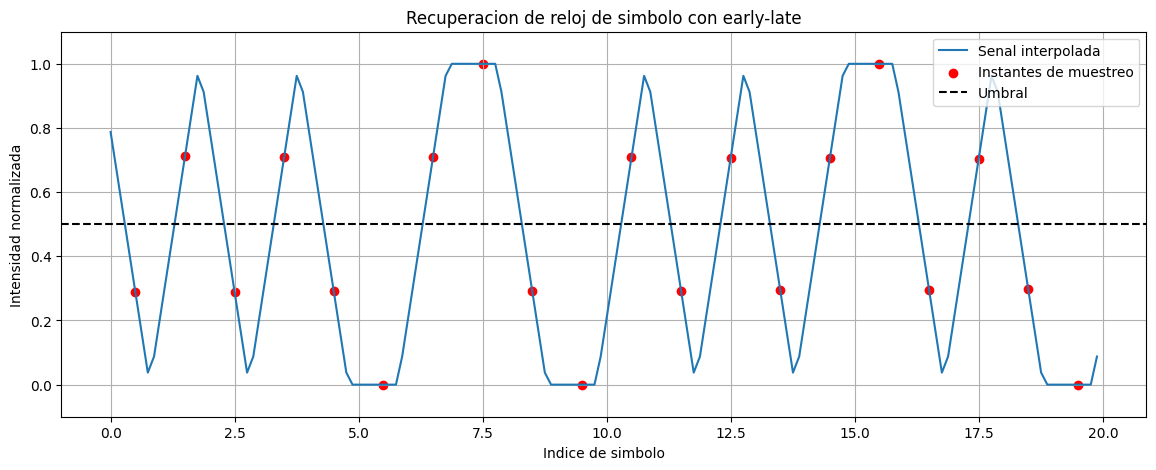

In [175]:
senal_datos_agc, posiciones_datos_rx, mascara_datos_rx = extraer_senal_datos(matriz_rx_agc)

muestras_por_simbolo = 8
senal_sobremuestreada = sobremuestrear_senal(
    senal_datos_agc,
    muestras_por_simbolo=muestras_por_simbolo,
    desfase=1.7
)

resultado_reloj = recuperar_reloj_early_late(
    senal_sobremuestreada,
    muestras_por_simbolo=muestras_por_simbolo,
    ganancia=0.05
)

simbolos_reloj = (resultado_reloj["muestras"] >= 0.5).astype(np.uint8)

# Para el frame espacial actual ya hay una muestra AGC por celda, asi que
# la sincronizacion de trama se hace sobre esos simbolos base. El bloque
# early-late queda listo para reemplazar esta entrada cuando se mida una
# senal temporal sobremuestreada desde video.
simbolos_para_sync = (senal_datos_agc >= 0.5).astype(np.uint8)

print("Cantidad de celdas de datos:", len(senal_datos_agc))
print("Cantidad de simbolos recuperados por reloj:", len(simbolos_reloj))
print("Cantidad de simbolos usados para sincronizar trama:", len(simbolos_para_sync))
print("Error early-late medio:", np.mean(resultado_reloj["errores"]))

num_muestras_grafica = min(160, len(senal_sobremuestreada))
num_simbolos_grafica = min(20, len(resultado_reloj["tiempos"]))

plt.figure(figsize=(14, 5))
plt.plot(
    np.arange(num_muestras_grafica) / muestras_por_simbolo,
    senal_sobremuestreada[:num_muestras_grafica],
    label="Senal interpolada"
)
plt.scatter(
    resultado_reloj["tiempos"][:num_simbolos_grafica] / muestras_por_simbolo,
    resultado_reloj["muestras"][:num_simbolos_grafica],
    color="red",
    label="Instantes de muestreo"
)
plt.axhline(0.5, color="k", linestyle="--", label="Umbral")
plt.title("Recuperacion de reloj de simbolo con early-late")
plt.xlabel("Indice de simbolo")
plt.ylabel("Intensidad normalizada")
plt.ylim(-0.1, 1.1)
plt.legend()
plt.grid(True)
plt.show()

### Sincronizacion de trama con preambulo

Luego de recuperar los simbolos OOK normalizados, se busca la secuencia Manchester del preambulo. La mejor correlacion indica donde empieza la trama util y permite retirar el preambulo antes de decodificar Manchester y reconstruir los caracteres ASCII.

Preambulos evaluados: ['1010101011110000', '1110100011010110']
Preambulo detectado: 1110100011010110
Indice de inicio del preambulo: 0
Correlacion maxima: 1.0
Simbolos Manchester despues del preambulo: 2108
Simbolos Manchester utiles antes del relleno: 816
Errores Manchester en payload util: 0

Mensaje recuperado despues de sincronizacion:
por favor no quiero perder comunicaciones digitales


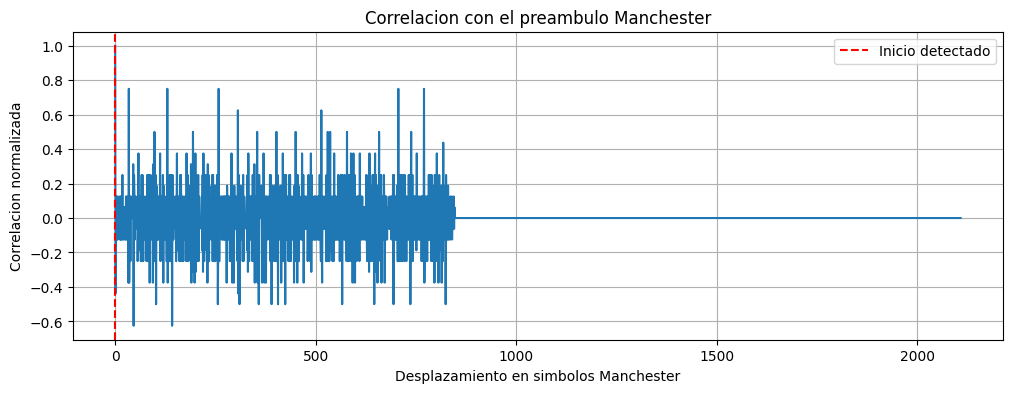

In [176]:
candidatos = preambulos_candidatos_fase_a()
resultado_sync = buscar_preambulo_manchester(simbolos_para_sync, candidatos)

inicio_preambulo = resultado_sync["indice"]
fin_preambulo = inicio_preambulo + len(resultado_sync["patron"])
simbolos_payload = simbolos_para_sync[fin_preambulo:]
simbolos_payload_util = recortar_relleno_manchester(simbolos_payload)

bits_payload, errores_manchester = decodificar_manchester_receptor(simbolos_payload_util)
mensaje_sync = bits_a_texto_ascii(bits_payload)

print("Preambulos evaluados:", candidatos)
print("Preambulo detectado:", resultado_sync["preambulo"])
print("Indice de inicio del preambulo:", inicio_preambulo)
print("Correlacion maxima:", resultado_sync["puntaje"])
print("Simbolos Manchester despues del preambulo:", len(simbolos_payload))
print("Simbolos Manchester utiles antes del relleno:", len(simbolos_payload_util))
print("Errores Manchester en payload util:", errores_manchester)
print("\nMensaje recuperado despues de sincronizacion:")
print(mensaje_sync)

plt.figure(figsize=(12, 4))
plt.plot(resultado_sync["correlaciones"])
plt.axvline(inicio_preambulo, color="red", linestyle="--", label="Inicio detectado")
plt.title("Correlacion con el preambulo Manchester")
plt.xlabel("Desplazamiento en simbolos Manchester")
plt.ylabel("Correlacion normalizada")
plt.legend()
plt.grid(True)
plt.show()

### Bloque para rolling shutter en video

Cuando se capturen varios frames, se puede formar un arreglo `[tiempo, fila, columna]` con las intensidades normalizadas. El retardo por fila se estima comparando señales piloto entre alturas distintas y luego se aplica una interpolación temporal que alinea todas las filas a una misma referencia temporal.

In [177]:
# Ejemplo de uso futuro con una secuencia real:
# secuencia_agc_video = np.stack(lista_de_matrices_agc, axis=0)
# retardos = estimar_retardos_enteros_por_fila(senales_piloto_por_fila)
# secuencia_compensada = compensar_rolling_shutter(
#     secuencia_agc_video,
#     retardo_por_fila_simbolos=retardo_estimado_por_fila
# )

secuencia_demo = matriz_rx_agc[np.newaxis, :, :]
secuencia_compensada_demo = compensar_rolling_shutter(
    secuencia_demo,
    retardo_por_fila_simbolos=0.0
)

print("Forma de secuencia demo:", secuencia_demo.shape)
print("Forma despues de compensar rolling shutter:", secuencia_compensada_demo.shape)
print("Nota: con un solo frame la compensacion temporal se deja como identidad.")

Forma de secuencia demo: (1, 36, 64)
Forma despues de compensar rolling shutter: (1, 36, 64)
Nota: con un solo frame la compensacion temporal se deja como identidad.


## Muestreo robusto y demapeo de simbolos

Una vez la pantalla esta rectificada y calibrada, el receptor debe convertir la imagen continua en una secuencia discreta de simbolos. Para cada celda de la grilla se toma solo la region central del macropixel, evitando los bordes donde la homografia, el desenfoque y la interpolacion pueden mezclar celdas vecinas.

Ademas, antes de promediar se aplica un filtrado de mediana dentro de cada celda. Esto reduce reflejos puntuales, ruido impulsivo y pixeles aislados sin cambiar demasiado el nivel global de intensidad.

In [178]:
# ============================================================
# FASE B.4 - MUESTREO ROBUSTO Y DEMAPEO DE SIMBOLOS
# ============================================================

def filtrar_mediana_parche(parche, kernel=3):
    if kernel is None or kernel <= 1:
        return parche

    kernel = int(kernel)

    if kernel % 2 == 0:
        kernel += 1

    return cv2.medianBlur(parche.astype(np.uint8), kernel)


def media_recortada(valores, proporcion_recorte=0.10):
    valores = np.sort(np.asarray(valores, dtype=np.float32).ravel())

    if len(valores) == 0:
        return np.nan

    k = int(len(valores) * proporcion_recorte)

    if 2 * k >= len(valores):
        return float(np.mean(valores))

    return float(np.mean(valores[k:len(valores) - k]))


def muestrear_celdas_robusto(img_rectificada, margen_relativo=0.25, kernel_mediana=3, proporcion_recorte=0.10):
    luminancia = convertir_a_luminancia(img_rectificada)
    matriz_muestreada = np.zeros((num_filas, num_columnas), dtype=np.float32)
    matriz_desviacion = np.zeros((num_filas, num_columnas), dtype=np.float32)

    margen = int(round(tam_celda * margen_relativo))

    for fila in range(num_filas):
        for columna in range(num_columnas):
            y0 = fila * tam_celda + margen
            y1 = (fila + 1) * tam_celda - margen
            x0 = columna * tam_celda + margen
            x1 = (columna + 1) * tam_celda - margen

            parche = luminancia[y0:y1, x0:x1]
            parche_filtrado = filtrar_mediana_parche(parche, kernel=kernel_mediana)

            matriz_muestreada[fila, columna] = media_recortada(
                parche_filtrado,
                proporcion_recorte=proporcion_recorte
            )
            matriz_desviacion[fila, columna] = np.std(parche_filtrado.astype(np.float32))

    return matriz_muestreada, matriz_desviacion


def aplicar_agc_a_matriz(matriz_celdas, resultado_agc):
    mapa_negro = resultado_agc["mapa_negro"]
    mapa_blanco = resultado_agc["mapa_blanco"]
    denominador = np.maximum(mapa_blanco - mapa_negro, 1e-6)

    normalizada = (matriz_celdas - mapa_negro) / denominador
    return np.clip(normalizada, 0, 1)


def demapear_ook(matriz_normalizada, umbral=0.5):
    return (matriz_normalizada >= umbral).astype(np.uint8)


def extraer_simbolos_datos_desde_bits(bits_celdas):
    mascara = construir_mascara_datos_receptor()
    posiciones = np.argwhere(mascara)
    simbolos = bits_celdas[mascara].astype(np.uint8)

    return simbolos, posiciones, mascara


def calcular_metricas_muestreo(matriz_normalizada, bits_celdas, referencia):
    mascara = ~np.isnan(referencia)
    esperados = referencia[mascara].astype(np.uint8)
    decididos = bits_celdas[mascara].astype(np.uint8)

    return {
        "celdas_conocidas": int(np.sum(mascara)),
        "errores_conocidos": int(np.sum(decididos != esperados)),
        "ber_conocidas": float(np.mean(decididos != esperados)),
        "media_negros": float(np.mean(matriz_normalizada[mascara & (referencia == 0)])),
        "media_blancos": float(np.mean(matriz_normalizada[mascara & (referencia == 1)])),
    }

### Muestreo de la grilla rectificada

La celda siguiente produce una matriz de valores medidos por celda. Tambien calcula una desviacion local por celda: valores altos pueden indicar reflejos, bordes mal alineados o zonas con mezcla entre blanco y negro.

Celdas totales muestreadas: 2304
Simbolos de datos extraidos: 2140
Celdas conocidas evaluadas: 164
Errores en pilotos/marcadores: 0
BER en celdas conocidas: 0.0
Media normalizada de negros conocidos: 0.0
Media normalizada de blancos conocidos: 1.0


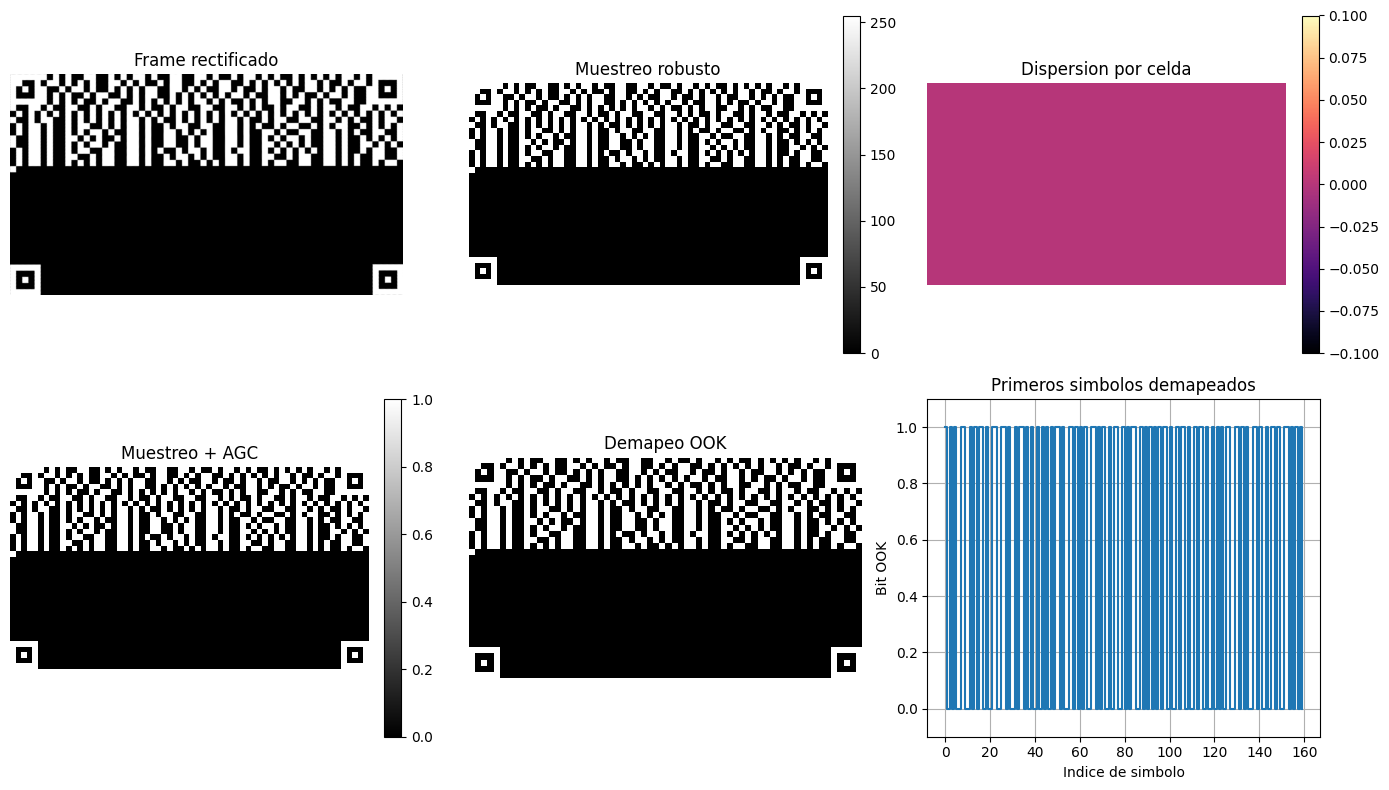

In [179]:
matriz_muestreada_raw, matriz_ruido_celda = muestrear_celdas_robusto(
    frame_rectificado,
    margen_relativo=0.25,
    kernel_mediana=3,
    proporcion_recorte=0.10
)

matriz_muestreada_agc = aplicar_agc_a_matriz(
    matriz_muestreada_raw,
    resultado_agc
)

bits_celdas_rx = demapear_ook(matriz_muestreada_agc, umbral=0.5)
simbolos_datos_rx, posiciones_simbolos_rx, mascara_simbolos_rx = extraer_simbolos_datos_desde_bits(bits_celdas_rx)

metricas_muestreo = calcular_metricas_muestreo(
    matriz_muestreada_agc,
    bits_celdas_rx,
    resultado_agc["referencia"]
)

print("Celdas totales muestreadas:", matriz_muestreada_raw.size)
print("Simbolos de datos extraidos:", len(simbolos_datos_rx))
print("Celdas conocidas evaluadas:", metricas_muestreo["celdas_conocidas"])
print("Errores en pilotos/marcadores:", metricas_muestreo["errores_conocidos"])
print("BER en celdas conocidas:", metricas_muestreo["ber_conocidas"])
print("Media normalizada de negros conocidos:", metricas_muestreo["media_negros"])
print("Media normalizada de blancos conocidos:", metricas_muestreo["media_blancos"])

plt.figure(figsize=(14, 8))

plt.subplot(2, 3, 1)
plt.imshow(frame_rectificado, cmap="gray", vmin=0, vmax=255)
plt.title("Frame rectificado")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(matriz_muestreada_raw, cmap="gray", vmin=0, vmax=255)
plt.title("Muestreo robusto")
plt.axis("off")
plt.colorbar(fraction=0.046, pad=0.04)

plt.subplot(2, 3, 3)
plt.imshow(matriz_ruido_celda, cmap="magma")
plt.title("Dispersion por celda")
plt.axis("off")
plt.colorbar(fraction=0.046, pad=0.04)

plt.subplot(2, 3, 4)
plt.imshow(matriz_muestreada_agc, cmap="gray", vmin=0, vmax=1)
plt.title("Muestreo + AGC")
plt.axis("off")
plt.colorbar(fraction=0.046, pad=0.04)

plt.subplot(2, 3, 5)
plt.imshow(bits_celdas_rx, cmap="gray", vmin=0, vmax=1)
plt.title("Demapeo OOK")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.plot(simbolos_datos_rx[:160], drawstyle="steps-post")
plt.title("Primeros simbolos demapeados")
plt.xlabel("Indice de simbolo")
plt.ylabel("Bit OOK")
plt.ylim(-0.1, 1.1)
plt.grid(True)

plt.tight_layout()
plt.show()

### Verificacion contra preambulo y Manchester

Como prueba de consistencia, los simbolos demapeados se pasan por la misma sincronizacion de preambulo y decodificacion Manchester. Si el muestreo esta bien alineado, el preambulo debe aparecer con alta correlacion y el mensaje reconstruido debe coincidir con el enviado.

Preambulo detectado: 1110100011010110
Indice de inicio: 0
Correlacion maxima: 1.0
Simbolos utiles: 816
Errores Manchester utiles: 0

Mensaje recuperado desde muestreo/demapeo:
por favor no quiero perder comunicaciones digitales


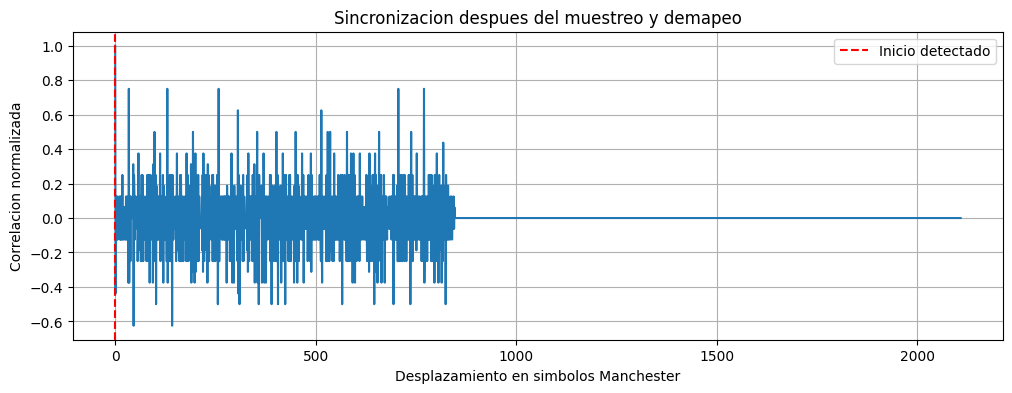

In [180]:
resultado_sync_muestreo = buscar_preambulo_manchester(
    simbolos_datos_rx,
    preambulos_candidatos_fase_a()
)

inicio_preambulo_muestreo = resultado_sync_muestreo["indice"]
fin_preambulo_muestreo = inicio_preambulo_muestreo + len(resultado_sync_muestreo["patron"])

payload_muestreo = simbolos_datos_rx[fin_preambulo_muestreo:]
payload_muestreo_util = recortar_relleno_manchester(payload_muestreo)

bits_payload_muestreo, errores_manchester_muestreo = decodificar_manchester_receptor(payload_muestreo_util)
mensaje_muestreo = bits_a_texto_ascii(bits_payload_muestreo)

print("Preambulo detectado:", resultado_sync_muestreo["preambulo"])
print("Indice de inicio:", inicio_preambulo_muestreo)
print("Correlacion maxima:", resultado_sync_muestreo["puntaje"])
print("Simbolos utiles:", len(payload_muestreo_util))
print("Errores Manchester utiles:", errores_manchester_muestreo)
print("\nMensaje recuperado desde muestreo/demapeo:")
print(mensaje_muestreo)

plt.figure(figsize=(12, 4))
plt.plot(resultado_sync_muestreo["correlaciones"])
plt.axvline(inicio_preambulo_muestreo, color="red", linestyle="--", label="Inicio detectado")
plt.title("Sincronizacion despues del muestreo y demapeo")
plt.xlabel("Desplazamiento en simbolos Manchester")
plt.ylabel("Correlacion normalizada")
plt.legend()
plt.grid(True)
plt.show()

## Codificacion de canal con Hamming (7,4)

Como primera tecnica de control de errores se implementa un codigo de bloque **Hamming (7,4)**. Este codigo toma grupos de 4 bits de datos y genera palabras de 7 bits agregando 3 bits de paridad. En recepcion permite corregir automaticamente un error de bit por cada palabra codificada.

Es una opcion sencilla para empezar porque no requiere librerias externas ni algoritmos iterativos. Si el canal optico produce errores en rafaga o mas de un error dentro del mismo bloque, se puede migrar despues a una tecnica mas fuerte como Reed-Solomon o convolucional.

In [181]:
# ============================================================
# FASE B.5 - CODIGO DE CANAL HAMMING (7,4)
# ============================================================

def hamming74_codificar_bloque(datos4):
    d1, d2, d3, d4 = np.asarray(datos4, dtype=np.uint8)

    p1 = d1 ^ d2 ^ d4
    p2 = d1 ^ d3 ^ d4
    p4 = d2 ^ d3 ^ d4

    return np.array([p1, p2, d1, p4, d2, d3, d4], dtype=np.uint8)


def hamming74_decodificar_bloque(codigo7):
    # Se fuerza cada entrada a 0/1. Esto evita que un valor invalido de
    # Manchester (-1 convertido a uint8 -> 255) produzca sindromes imposibles.
    recibido = np.asarray(codigo7, dtype=np.int16).copy()
    recibido = np.where(recibido > 0, 1, 0).astype(np.uint8)

    s1 = int(recibido[0] ^ recibido[2] ^ recibido[4] ^ recibido[6])
    s2 = int(recibido[1] ^ recibido[2] ^ recibido[5] ^ recibido[6])
    s4 = int(recibido[3] ^ recibido[4] ^ recibido[5] ^ recibido[6])

    sindrome = s1 + 2 * s2 + 4 * s4
    corregido = False

    if 1 <= sindrome <= 7:
        indice_error = sindrome - 1
        recibido[indice_error] ^= 1
        corregido = True

    datos = recibido[[2, 4, 5, 6]]

    return datos.astype(np.uint8), sindrome, corregido


def hamming74_codificar_bits(bits):
    bits = np.asarray(bits, dtype=np.uint8)
    longitud_original = len(bits)
    relleno = (-longitud_original) % 4

    if relleno > 0:
        bits = np.concatenate([bits, np.zeros(relleno, dtype=np.uint8)])

    bloques = bits.reshape(-1, 4)
    codificados = [hamming74_codificar_bloque(bloque) for bloque in bloques]

    return np.concatenate(codificados), longitud_original, relleno


def hamming74_decodificar_bits(bits_codificados, longitud_original=None):
    bits_codificados = np.asarray(bits_codificados, dtype=np.uint8)

    if len(bits_codificados) % 7 != 0:
        raise ValueError("La longitud recibida no es multiplo de 7.")

    bloques = bits_codificados.reshape(-1, 7)
    datos_decodificados = []
    sindromes = []
    bloques_corregidos = 0

    for bloque in bloques:
        datos, sindrome, corregido = hamming74_decodificar_bloque(bloque)
        datos_decodificados.append(datos)
        sindromes.append(sindrome)

        if corregido:
            bloques_corregidos += 1

    datos_decodificados = np.concatenate(datos_decodificados).astype(np.uint8)

    if longitud_original is not None:
        datos_decodificados = datos_decodificados[:longitud_original]

    return {
        "bits": datos_decodificados,
        "sindromes": np.array(sindromes, dtype=np.uint8),
        "bloques_corregidos": bloques_corregidos,
        "num_bloques": len(bloques)
    }



def hamming74_corregir_bloques(bits_codificados):
    bits_codificados = np.asarray(bits_codificados, dtype=np.int16)
    bits_codificados = np.where(bits_codificados > 0, 1, 0).astype(np.uint8)
    bits_codificados = bits_codificados[:(len(bits_codificados) // 7) * 7]
    bloques = bits_codificados.reshape(-1, 7)

    bloques_corregidos = []
    datos_decodificados = []
    resumen = []

    for indice, bloque in enumerate(bloques):
        datos, sindrome, corregido = hamming74_decodificar_bloque(bloque)
        bloque_corregido = bloque.copy()

        if 1 <= sindrome <= 7:
            bloque_corregido[sindrome - 1] ^= 1

        bloques_corregidos.append(bloque_corregido)
        datos_decodificados.append(datos)
        resumen.append({
            "bloque": indice,
            "sindrome": int(sindrome),
            "bit_corregido": int(sindrome - 1) if sindrome != 0 else None,
            "recibido": "".join(str(int(b)) for b in bloque),
            "corregido": "".join(str(int(b)) for b in bloque_corregido),
        })

    if datos_decodificados:
        bits_decodificados = np.concatenate(datos_decodificados).astype(np.uint8)
        bits_corregidos = np.concatenate(bloques_corregidos).astype(np.uint8)
    else:
        bits_decodificados = np.array([], dtype=np.uint8)
        bits_corregidos = np.array([], dtype=np.uint8)

    return {
        "bits_corregidos": bits_corregidos,
        "bits_decodificados": bits_decodificados,
        "resumen": resumen,
    }


def inyectar_errores_simples_hamming(bits_codificados, num_bloques_con_error=8, semilla=7):
    rng = np.random.default_rng(semilla)
    recibido = np.asarray(bits_codificados, dtype=np.uint8).copy()
    num_bloques = len(recibido) // 7
    num_bloques_con_error = min(num_bloques_con_error, num_bloques)

    bloques_error = rng.choice(num_bloques, size=num_bloques_con_error, replace=False)
    posiciones_error = []

    for bloque in bloques_error:
        posicion_local = int(rng.integers(0, 7))
        posicion_global = int(7 * bloque + posicion_local)
        recibido[posicion_global] ^= 1
        posiciones_error.append(posicion_global)

    return recibido, np.array(posiciones_error, dtype=np.int32)


def bits_a_cadena(bits, max_bits=80):
    bits = np.asarray(bits).astype(int)
    texto = "".join(str(b) for b in bits[:max_bits])

    if len(bits) > max_bits:
        texto += "..."

    return texto

### Prueba con errores residuales

La siguiente prueba codifica los bits del mensaje, inyecta errores simples en diferentes bloques y luego decodifica. Si hay como maximo un error por bloque Hamming, el receptor debe corregirlos y recuperar exactamente la secuencia original.

Bits utiles originales: 408
Bits codificados Hamming: 714
Relleno agregado: 0
Errores inyectados: 10
Bloques corregidos: 10
Errores residuales despues de decodificar: 0

Primeros bits originales:
01110000011011110111001000100000011001100110000101110110011011110111001000100000...

Primeros bits recibidos con errores:
00011110000000110011011111110001111010101001010100000000110010011001101100110110...

Primeros bits decodificados:
01110000011011110111001000100000011001100110000101110110011011110111001000100000...


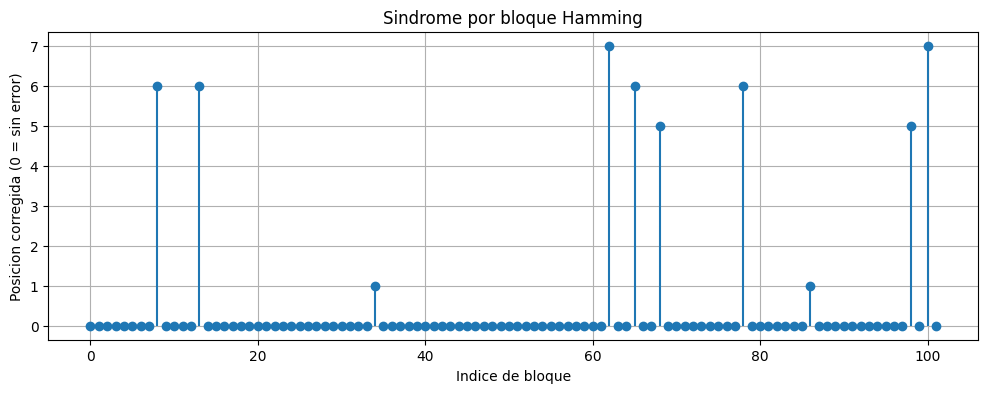

In [182]:
if "bits_array" not in globals():
    if "mensaje" not in globals():
        mensaje = "el mas perron del pedazo"

    bits_array = np.array(
        [int(bit) for caracter in mensaje for bit in format(ord(caracter), "08b")],
        dtype=np.uint8
    )

bits_hamming_tx, longitud_bits_utiles, relleno_hamming = hamming74_codificar_bits(bits_array)

bits_hamming_rx, posiciones_error_hamming = inyectar_errores_simples_hamming(
    bits_hamming_tx,
    num_bloques_con_error=10,
    semilla=14
)

resultado_hamming = hamming74_decodificar_bits(
    bits_hamming_rx,
    longitud_original=longitud_bits_utiles
)

bits_hamming_decodificados = resultado_hamming["bits"]
errores_residuales = np.sum(bits_hamming_decodificados != bits_array)

print("Bits utiles originales:", len(bits_array))
print("Bits codificados Hamming:", len(bits_hamming_tx))
print("Relleno agregado:", relleno_hamming)
print("Errores inyectados:", len(posiciones_error_hamming))
print("Bloques corregidos:", resultado_hamming["bloques_corregidos"])
print("Errores residuales despues de decodificar:", errores_residuales)
print("\nPrimeros bits originales:")
print(bits_a_cadena(bits_array))
print("\nPrimeros bits recibidos con errores:")
print(bits_a_cadena(bits_hamming_rx))
print("\nPrimeros bits decodificados:")
print(bits_a_cadena(bits_hamming_decodificados))

plt.figure(figsize=(12, 4))
plt.stem(
    resultado_hamming["sindromes"],
    basefmt=" "
)
plt.title("Sindrome por bloque Hamming")
plt.xlabel("Indice de bloque")
plt.ylabel("Posicion corregida (0 = sin error)")
plt.grid(True)
plt.show()

### Ubicacion dentro del modem

Para usar este codigo en la transmision completa, el orden recomendado es:

`texto -> bits ASCII -> Hamming (7,4) -> preambulo -> Manchester -> OOK -> grilla`

En recepcion se invierte el proceso:

`grilla -> OOK -> sincronizacion -> Manchester -> Hamming (7,4) -> bits ASCII -> texto`

El frame actual del notebook fue generado sin Hamming, por eso esta seccion se valida como bloque independiente. En el siguiente ajuste se puede insertar el codificador en la Fase A y regenerar el frame protegido.

In [183]:
# Ejemplo compacto de integracion en transmision:
if "preambulo_array" not in globals():
    preambulo_array = np.array([int(b) for b in "1110100011010110"], dtype=np.uint8)

bits_payload_protegidos, longitud_payload_original, relleno_payload = hamming74_codificar_bits(bits_array)
bits_tx_protegidos = np.concatenate([preambulo_array, bits_payload_protegidos])

# En recepcion, despues de sincronizar trama y decodificar Manchester:
# resultado_fec = hamming74_decodificar_bits(bits_payload_rx, longitud_original=longitud_payload_original)
# bits_payload_corregidos = resultado_fec["bits"]
# mensaje_corregido = bits_a_texto_ascii(bits_payload_corregidos)

print("Tasa de codigo Hamming (7,4):", 4 / 7)
print("Bits de payload sin proteccion:", len(bits_array))
print("Bits de payload protegido:", len(bits_payload_protegidos))
print("Sobrecosto porcentual:", 100 * (len(bits_payload_protegidos) / len(bits_array) - 1), "%")

Tasa de codigo Hamming (7,4): 0.5714285714285714
Bits de payload sin proteccion: 408
Bits de payload protegido: 714
Sobrecosto porcentual: 75.0 %


## Prueba con camara

Esta seccion es la prueba extremo a extremo con camara real. Aqui se define un mensaje nuevo, se genera un frame protegido con Hamming, Manchester, OOK, preambulo, pilotos y marcadores; luego se guarda como PNG para mostrarlo en otra pantalla. Despues se captura una foto y se ejecuta el receptor de Fase B completo sobre esa imagen.

La captura real no se ejecuta durante la Fase B normal. Solo ocurre en esta seccion cuando `USAR_CAMARA_PRUEBA = 1`.

Frame para prueba con camara guardado como: frame_tx_prueba_camara_hamming.png
Mensaje TX: Luicilla la maravilla
Bits payload: 168
Bits payload con Hamming: 294
Bits Manchester transmitidos: 620
Relleno Hamming: 0


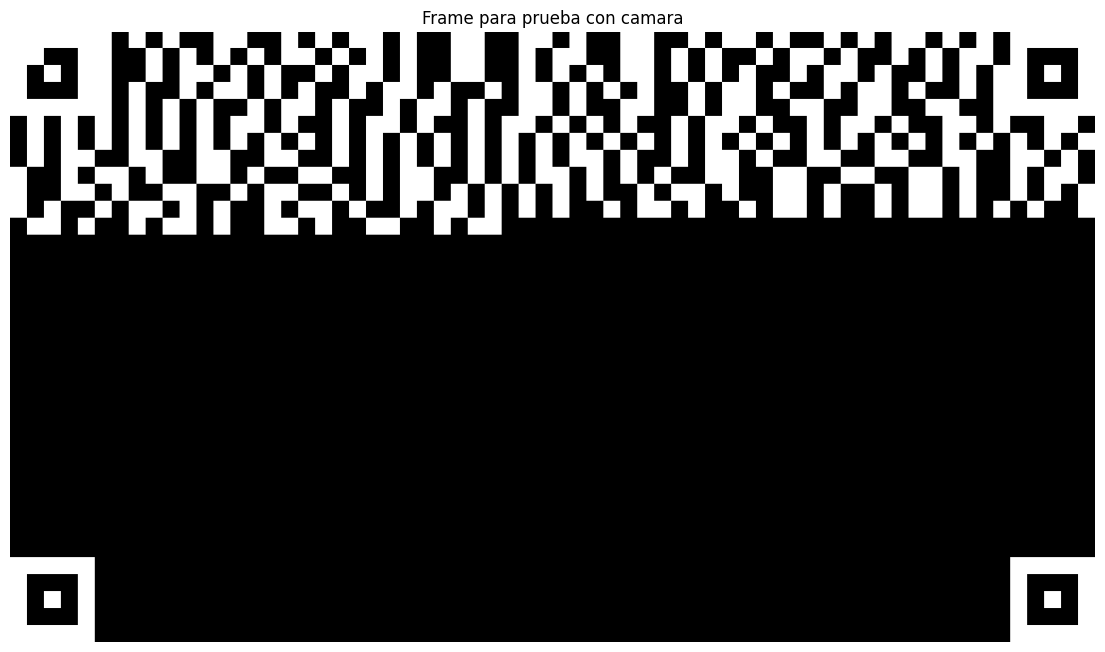

In [189]:
# ============================================================
# PRUEBA CON CAMARA - CONFIGURACION Y FRAME TX
# ============================================================

# Mensaje editable para la prueba final con camara.
MENSAJE_PRUEBA_CAMARA = "Luicilla la maravilla"

# Archivo que debes abrir en la otra pantalla para tomar la foto.
RUTA_FRAME_PRUEBA_CAMARA = "frame_tx_prueba_camara_hamming.png"


def texto_a_bits_ascii(texto):
    return np.array(
        [int(bit) for caracter in texto for bit in format(ord(caracter), "08b")],
        dtype=np.uint8
    )


def insertar_pilotos_receptor(matriz):
    matriz = matriz.copy()

    for col in range(num_columnas):
        matriz[fila_pilotos, col] = 0 if col % 2 == 0 else 255

    return matriz


def insertar_marcadores_receptor(matriz):
    matriz = matriz.copy()
    matriz[0:tam_marcador, 0:tam_marcador] = marcador_orientacion
    matriz[0:tam_marcador, -tam_marcador:] = marcador_normal
    matriz[-tam_marcador:, 0:tam_marcador] = marcador_normal
    matriz[-tam_marcador:, -tam_marcador:] = marcador_normal

    return matriz


def generar_frame_prueba_camara(mensaje_tx, ruta_salida):
    bits_payload = texto_a_bits_ascii(mensaje_tx)
    bits_payload_hamming, longitud_original, relleno_hamming = hamming74_codificar_bits(bits_payload)

    preambulo_local = np.array([int(b) for b in "1110100011010110"], dtype=np.uint8)
    bits_tx_local = np.concatenate([preambulo_local, bits_payload_hamming])
    bits_manchester_local = codificar_manchester_receptor(bits_tx_local)
    simbolos_ook_local = np.where(bits_manchester_local == 0, 0, 255).astype(np.uint8)

    matriz_tx_local = np.zeros((num_filas, num_columnas), dtype=np.uint8)
    mascara_datos_local = construir_mascara_datos_receptor()
    posiciones_datos_local = np.argwhere(mascara_datos_local)

    if len(simbolos_ook_local) > len(posiciones_datos_local):
        raise ValueError(
            "El mensaje protegido no cabe en la grilla actual. "
            "Reduce el mensaje o aumenta la capacidad de la grilla."
        )

    for simbolo, (fila, columna) in zip(simbolos_ook_local, posiciones_datos_local):
        matriz_tx_local[fila, columna] = simbolo

    matriz_tx_local = insertar_pilotos_receptor(matriz_tx_local)
    matriz_tx_local = insertar_marcadores_receptor(matriz_tx_local)

    frame_tx_local = np.kron(
        matriz_tx_local,
        np.ones((tam_celda, tam_celda), dtype=np.uint8)
    )

    cv2.imwrite(ruta_salida, frame_tx_local)

    return {
        "mensaje": mensaje_tx,
        "bits_payload": bits_payload,
        "bits_payload_hamming": bits_payload_hamming,
        "longitud_original": longitud_original,
        "relleno_hamming": relleno_hamming,
        "bits_manchester": bits_manchester_local,
        "matriz_tx": matriz_tx_local,
        "frame_tx": frame_tx_local,
        "ruta": ruta_salida
    }


prueba_tx_camara = generar_frame_prueba_camara(
    MENSAJE_PRUEBA_CAMARA,
    RUTA_FRAME_PRUEBA_CAMARA
)

print("Frame para prueba con camara guardado como:", prueba_tx_camara["ruta"])
print("Mensaje TX:", prueba_tx_camara["mensaje"])
print("Bits payload:", len(prueba_tx_camara["bits_payload"]))
print("Bits payload con Hamming:", len(prueba_tx_camara["bits_payload_hamming"]))
print("Bits Manchester transmitidos:", len(prueba_tx_camara["bits_manchester"]))
print("Relleno Hamming:", prueba_tx_camara["relleno_hamming"])

plt.figure(figsize=(14, 8))
plt.imshow(prueba_tx_camara["frame_tx"], cmap="gray", vmin=0, vmax=255)
plt.title("Frame para prueba con camara")
plt.axis("off")
plt.show()

### Captura y recepcion de la prueba con camara

Despues de ejecutar la celda anterior, abre el PNG generado en otra pantalla. En la celda siguiente puedes usar `USAR_CAMARA_PRUEBA = 1` para capturar una foto con la barra espaciadora. Si quieres probar el flujo sin camara, deja `USAR_CAMARA_PRUEBA = 0` y se usara una captura sintetica del mismo frame protegido.

Camara abierta.
Presiona ESPACIO para capturar.
Presiona ESC o Q para cancelar.
Foto guardada en: data/captura_prueba_camara.png
Se procesara la foto capturada desde camara.
Recorte manual aplicado (pixeles): (102, 129, 1177, 561)
Mensaje TX:
Luicilla la maravilla

Mensaje RX despues de Hamming:
0?

Correlacion de preambulo: 0.5625
ADVERTENCIA: correlacion baja. La ROI/recorte probablemente no esta alineando bien el frame.
Ajusta RECORTE_MANUAL_NORMALIZADO_PRUEBA para encerrar solo la pantalla/codigo.
Errores Manchester: 181
Bits invalidos desde Manchester: 181
Bloques Hamming corregidos: 30
Errores residuales despues de Hamming: 86

Primeros bloques corregidos:
Bloque 0 | sindrome: 7 | bit corregido: 6 | 1000010 -> 1000011
Bloque 2 | sindrome: 7 | bit corregido: 6 | 0110010 -> 0110011
Bloque 3 | sindrome: 4 | bit corregido: 3 | 1010010 -> 1011010
Bloque 4 | sindrome: 6 | bit corregido: 5 | 0000010 -> 0000000
Bloque 6 | sindrome: 6 | bit corregido: 5 | 0000010 -> 0000000
Bloque 9 | sin

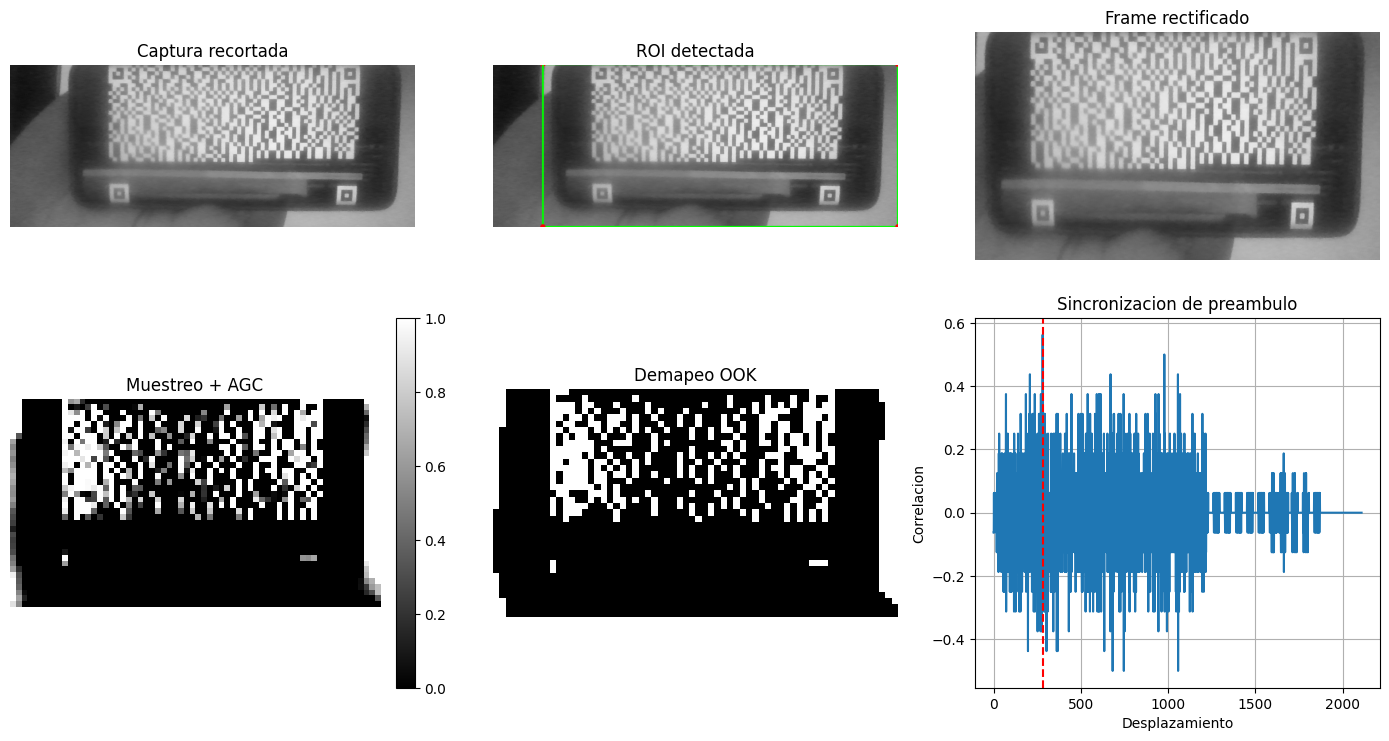

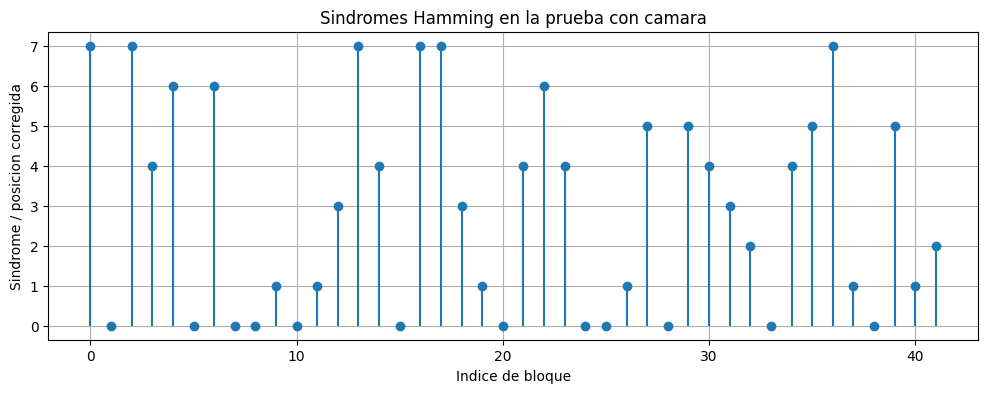

In [193]:
# ============================================================
# PRUEBA CON CAMARA - CAPTURA Y RECEPCION FASE B
# ============================================================

# 1 -> abrir camara y capturar con barra espaciadora
# 0 -> usar captura sintetica del frame generado en la celda anterior
USAR_CAMARA_PRUEBA = 1

INDICE_CAMARA_PRUEBA = 0
BACKEND_CAMARA_PRUEBA = "MSMF"  # opciones: "DSHOW", "MSMF", "AUTO"
RUTA_CAPTURA_PRUEBA_CAMARA = "data/captura_prueba_camara.png"

# Si la deteccion de ROI toma fondo/mano en vez del frame, activa este recorte.
# Formato normalizado: (x0, y0, x1, y1), con valores entre 0 y 1.
# Ajusta estos numeros mirando la grafica "Captura de entrada".
USAR_RECORTE_MANUAL_PRUEBA = 1
RECORTE_MANUAL_NORMALIZADO_PRUEBA = (0.08, 0.18, 0.92, 0.78)

# Opcional: fuerza algunos errores despues de Manchester para ver bloques corregidos.
INYECTAR_ERRORES_DEMO_HAMMING_CAMARA = 0


def obtener_backend_camara(nombre_backend):
    nombre_backend = str(nombre_backend).upper()

    if nombre_backend == "DSHOW":
        return cv2.CAP_DSHOW

    if nombre_backend == "MSMF":
        return cv2.CAP_MSMF

    return 0


def capturar_imagen_desde_camara(indice_camara=0, ruta_salida="data/captura_prueba_camara.png", backend_preferido="DSHOW"):
    backend = obtener_backend_camara(backend_preferido)
    camara = cv2.VideoCapture(indice_camara, backend)

    if not camara.isOpened() and str(backend_preferido).upper() != "AUTO":
        print("No se pudo abrir con", backend_preferido, ". Intentando backend AUTO...")
        camara.release()
        camara = cv2.VideoCapture(indice_camara)

    if not camara.isOpened():
        raise RuntimeError(
            "No se pudo abrir la camara. Prueba otro INDICE_CAMARA_PRUEBA o BACKEND_CAMARA_PRUEBA."
        )

    camara.set(cv2.CAP_PROP_FRAME_WIDTH, 1280)
    camara.set(cv2.CAP_PROP_FRAME_HEIGHT, 720)

    foto = None
    nombre_ventana = "Prueba con camara - Fase B"

    print("Camara abierta.")
    print("Presiona ESPACIO para capturar.")
    print("Presiona ESC o Q para cancelar.")

    try:
        while True:
            ok, frame = camara.read()

            if not ok:
                continue

            vista = frame.copy()
            cv2.putText(
                vista,
                "ESPACIO: capturar | ESC/Q: cancelar",
                (25, 40),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.9,
                (0, 255, 0),
                2,
                cv2.LINE_AA
            )

            cv2.imshow(nombre_ventana, vista)
            tecla = cv2.waitKey(1) & 0xFF

            if tecla == 32:
                foto = frame.copy()
                os.makedirs(os.path.dirname(ruta_salida), exist_ok=True)
                cv2.imwrite(ruta_salida, foto)
                print("Foto guardada en:", ruta_salida)
                break

            if tecla in (27, ord("q"), ord("Q")):
                break

    finally:
        camara.release()
        cv2.destroyAllWindows()

    if foto is None:
        raise RuntimeError("La captura fue cancelada o no se obtuvo ninguna imagen.")

    return foto


def crear_captura_sintetica_desde_frame(frame_base):
    alto_canvas_local = 1000
    ancho_canvas_local = 1500

    puntos_frame_local = np.float32([
        [0, 0],
        [ancho_img - 1, 0],
        [ancho_img - 1, alto_img - 1],
        [0, alto_img - 1]
    ])

    puntos_camara_local = np.float32([
        [180, 140],
        [1320, 80],
        [1240, 830],
        [260, 900]
    ])

    H_local = cv2.getPerspectiveTransform(puntos_frame_local, puntos_camara_local)
    return cv2.warpPerspective(
        frame_base,
        H_local,
        (ancho_canvas_local, alto_canvas_local),
        borderValue=0
    )


def aplicar_recorte_manual(img, recorte_normalizado):
    h, w = img.shape[:2]
    x0, y0, x1, y1 = recorte_normalizado

    x0 = int(np.clip(x0, 0, 1) * w)
    x1 = int(np.clip(x1, 0, 1) * w)
    y0 = int(np.clip(y0, 0, 1) * h)
    y1 = int(np.clip(y1, 0, 1) * h)

    if x1 <= x0 or y1 <= y0:
        raise ValueError("El recorte manual no es valido. Revisa RECORTE_MANUAL_NORMALIZADO_PRUEBA.")

    return img[y0:y1, x0:x1], (x0, y0, x1, y1)


if USAR_CAMARA_PRUEBA == 1:
    captura_bgr_prueba = capturar_imagen_desde_camara(
        indice_camara=INDICE_CAMARA_PRUEBA,
        ruta_salida=RUTA_CAPTURA_PRUEBA_CAMARA,
        backend_preferido=BACKEND_CAMARA_PRUEBA
    )
    img_prueba_original = cv2.cvtColor(captura_bgr_prueba, cv2.COLOR_BGR2GRAY)
    es_captura_real_prueba = True
    print("Se procesara la foto capturada desde camara.")
else:
    img_prueba_original = crear_captura_sintetica_desde_frame(prueba_tx_camara["frame_tx"])
    es_captura_real_prueba = False
    print("Se procesara una captura sintetica del frame de prueba.")

if USAR_RECORTE_MANUAL_PRUEBA == 1 and es_captura_real_prueba:
    img_prueba_camara, recorte_usado_prueba = aplicar_recorte_manual(
        img_prueba_original,
        RECORTE_MANUAL_NORMALIZADO_PRUEBA
    )
    print("Recorte manual aplicado (pixeles):", recorte_usado_prueba)
else:
    img_prueba_camara = img_prueba_original
    recorte_usado_prueba = None


# Receptor Fase B completo sobre la imagen de prueba
esquinas_roi_prueba, mascara_roi_prueba = detectar_cuadrilatero_roi(img_prueba_camara)
resultado_rectificacion_prueba = rectificar_con_orientacion(img_prueba_camara, esquinas_roi_prueba)
frame_rectificado_prueba = resultado_rectificacion_prueba["rectificada"]

matriz_intensidad_prueba = promediar_celdas(frame_rectificado_prueba)
resultado_agc_prueba = calibrar_agc_celdas(matriz_intensidad_prueba)

matriz_muestreada_raw_prueba, matriz_ruido_prueba = muestrear_celdas_robusto(
    frame_rectificado_prueba,
    margen_relativo=0.25,
    kernel_mediana=3,
    proporcion_recorte=0.10
)

matriz_muestreada_agc_prueba = aplicar_agc_a_matriz(
    matriz_muestreada_raw_prueba,
    resultado_agc_prueba
)

bits_celdas_prueba = demapear_ook(matriz_muestreada_agc_prueba, umbral=0.5)
simbolos_datos_prueba, posiciones_datos_prueba, mascara_datos_prueba = extraer_simbolos_datos_desde_bits(bits_celdas_prueba)

sync_prueba = buscar_preambulo_manchester(
    simbolos_datos_prueba,
    ["1110100011010110"]
)

inicio_preambulo_prueba = sync_prueba["indice"]
fin_preambulo_prueba = inicio_preambulo_prueba + len(sync_prueba["patron"])
num_simbolos_payload_esperado = len(prueba_tx_camara["bits_payload_hamming"]) * 2

simbolos_payload_prueba = simbolos_datos_prueba[
    fin_preambulo_prueba:fin_preambulo_prueba + num_simbolos_payload_esperado
]

bits_payload_hamming_rx, errores_manchester_prueba = decodificar_manchester_receptor(simbolos_payload_prueba)
bits_invalidos_prueba = int(np.sum(bits_payload_hamming_rx < 0))
bits_hamming_duros_prueba = np.where(bits_payload_hamming_rx > 0, 1, 0).astype(np.uint8)

if INYECTAR_ERRORES_DEMO_HAMMING_CAMARA == 1:
    posiciones_demo = np.arange(0, min(len(bits_hamming_duros_prueba), 7 * 6), 7) + 2
    for posicion in posiciones_demo:
        bits_hamming_duros_prueba[posicion] ^= 1
    print("Errores demo inyectados en posiciones:", posiciones_demo.tolist())

fec_prueba = hamming74_corregir_bloques(bits_hamming_duros_prueba)
bits_payload_corregidos_prueba = fec_prueba["bits_decodificados"][:prueba_tx_camara["longitud_original"]]
mensaje_rx_prueba = bits_a_texto_ascii(bits_payload_corregidos_prueba)

bloques_corregidos_prueba = [
    item for item in fec_prueba["resumen"]
    if item["sindrome"] != 0
]

errores_residuales_prueba = np.sum(
    bits_payload_corregidos_prueba != prueba_tx_camara["bits_payload"][:len(bits_payload_corregidos_prueba)]
)

print("Mensaje TX:")
print(prueba_tx_camara["mensaje"])
print("\nMensaje RX despues de Hamming:")
print(mensaje_rx_prueba)
print("\nCorrelacion de preambulo:", sync_prueba["puntaje"])
if sync_prueba["puntaje"] < 0.75:
    print("ADVERTENCIA: correlacion baja. La ROI/recorte probablemente no esta alineando bien el frame.")
    print("Ajusta RECORTE_MANUAL_NORMALIZADO_PRUEBA para encerrar solo la pantalla/codigo.")
print("Errores Manchester:", errores_manchester_prueba)
print("Bits invalidos desde Manchester:", bits_invalidos_prueba)
print("Bloques Hamming corregidos:", len(bloques_corregidos_prueba))
print("Errores residuales despues de Hamming:", errores_residuales_prueba)

print("\nPrimeros bloques corregidos:")
for item in bloques_corregidos_prueba[:12]:
    print(
        "Bloque", item["bloque"],
        "| sindrome:", item["sindrome"],
        "| bit corregido:", item["bit_corregido"],
        "|", item["recibido"], "->", item["corregido"]
    )

plt.figure(figsize=(14, 8))

plt.subplot(2, 3, 1)
plt.imshow(img_prueba_camara, cmap="gray", vmin=0, vmax=255)
if recorte_usado_prueba is None:
    plt.title("Captura de entrada")
else:
    plt.title("Captura recortada")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(dibujar_roi(img_prueba_camara, esquinas_roi_prueba))
plt.title("ROI detectada")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(frame_rectificado_prueba, cmap="gray", vmin=0, vmax=255)
plt.title("Frame rectificado")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(matriz_muestreada_agc_prueba, cmap="gray", vmin=0, vmax=1)
plt.title("Muestreo + AGC")
plt.axis("off")
plt.colorbar(fraction=0.046, pad=0.04)

plt.subplot(2, 3, 5)
plt.imshow(bits_celdas_prueba, cmap="gray", vmin=0, vmax=1)
plt.title("Demapeo OOK")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.plot(sync_prueba["correlaciones"])
plt.axvline(inicio_preambulo_prueba, color="red", linestyle="--")
plt.title("Sincronizacion de preambulo")
plt.xlabel("Desplazamiento")
plt.ylabel("Correlacion")
plt.grid(True)

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
plt.stem([item["sindrome"] for item in fec_prueba["resumen"]], basefmt=" ")
plt.title("Sindromes Hamming en la prueba con camara")
plt.xlabel("Indice de bloque")
plt.ylabel("Sindrome / posicion corregida")
plt.grid(True)
plt.show()